# JSP/FJSP Encoding + F-VQE

This notebook implements the Journal paper **"Highly Efficient Encoding for Job-Shop Scheduling Problems and its Application on Quantum Computers"** 

1. Define a job-shop scheduling problem.
2. Encode/decode schedules using a compact integer/bitstring representation.
3. Calculate the raw cost, which is the **makespan**.
4. Convert raw cost into a filtered reward for F-VQE.
5. Use a simple simulated variational quantum circuit to search for good schedules.

This notebook is self-contained and uses only `numpy`.

## High-Level Architecture

```mermaid
flowchart TD
    A[Input JSP/FJSP problem] --> B[Build operations and machine options]
    B --> C[Compact encoding space]
    C --> D[Decode integer or bitstring]
    D --> E[Operation order + machine choices]
    E --> F[Build earliest-start schedule]
    F --> G[Raw cost: makespan]

    G --> H[Filter function]
    H --> I[Filtered reward]

    J[Parameterized quantum circuit] --> K[Statevector probabilities]
    K --> L[Sample bitstrings]
    L --> D
    I --> M[F-VQE / SPSA parameter update]
    M --> J

    G --> N[Best schedule found]
```

A very short summary:

- **Encoding layer:** turns bitstrings into valid schedules.
- **Cost layer:** calculates makespan.
- **Filter layer:** gives better schedules larger reward.
- **F-VQE layer:** changes circuit parameters to sample better bitstrings more often.

## 1. Imports and Data Structures

We use `dataclass` to store data neatly.

- `MachineOption`: one machine choice for one operation.
- `Operation`: one task inside a job.
- `Problem`: the complete JSP/FJSP instance.
- `ScheduledOperation`: one operation after it has been placed on a timeline.

In [1]:
from dataclasses import dataclass
from math import ceil, factorial, log2
import numpy as np


@dataclass(frozen=True)
class MachineOption:
    """A possible machine and processing time for one operation."""

    machine: str
    duration: int


@dataclass(frozen=True)
class Operation:
    """One operation belonging to one job."""

    op_id: int          # global operation number: 0, 1, 2, ...
    job_id: int         # which job this operation belongs to
    step_id: int        # position inside its job: first step, second step, ...
    options: tuple      # possible MachineOption objects


@dataclass(frozen=True)
class ScheduledOperation:
    """An operation after scheduling, with start and finish times."""

    operation: Operation
    machine: str
    duration: int
    start: int
    finish: int


class Problem:
    """A complete JSP or flexible JSP problem."""

    def __init__(self, jobs):
        self.jobs = tuple(jobs)

    @property
    def operations(self):
        """Return all operations in one flat list."""
        all_ops = []
        for job in self.jobs:
            for operation in job:
                all_ops.append(operation)
        return tuple(all_ops)

    @property
    def job_sizes(self):
        """Return how many operations are in each job."""
        return tuple(len(job) for job in self.jobs)

    @property
    def operation_count(self):
        return sum(self.job_sizes)

    @property
    def machine_config_count(self):
        """Number of possible machine-choice combinations."""
        total = 1
        for operation in self.operations:
            total = total * len(operation.options)
        return total

## 2. Build a Problem from Easy Input

We will describe each job as a list of operations.

For a normal JSP operation:

```python
("M1", 3)
```

means machine `M1` takes 3 time units.

For a flexible JSP operation:

```python
[("M1", 3), ("M2", 5)]
```

means the operation can run on `M1` in 3 units or `M2` in 5 units.

In [2]:
def convert_to_machine_options(raw_operation):
    """Convert user-friendly input into MachineOption objects."""

    # Case 1: normal JSP operation, for example ("M1", 3)
    if len(raw_operation) == 2 and isinstance(raw_operation[0], str):
        machine_name = raw_operation[0]
        duration = raw_operation[1]
        return (MachineOption(machine_name, duration),)

    # Case 2: flexible JSP operation, for example [("M1", 3), ("M2", 5)]
    options = []
    for machine_name, duration in raw_operation:
        options.append(MachineOption(machine_name, duration))
    return tuple(options)


def make_problem(raw_jobs):
    """Create a Problem object from simple nested Python lists."""

    jobs = []
    next_operation_id = 0

    for job_id, raw_job in enumerate(raw_jobs):
        job_operations = []

        for step_id, raw_operation in enumerate(raw_job):
            machine_options = convert_to_machine_options(raw_operation)

            operation = Operation(
                op_id=next_operation_id,
                job_id=job_id,
                step_id=step_id,
                options=machine_options,
            )

            job_operations.append(operation)
            next_operation_id = next_operation_id + 1

        jobs.append(tuple(job_operations))

    return Problem(tuple(jobs))

## 3. Count the Compact Encoding Space

The paper avoids representing invalid operation orders.

If job sizes are `[3, 2]`, then we need all sequences containing:

```text
J0, J0, J0, J1, J1
```

The number of valid job-order sequences is:

```text
(total operations)! / ((job 0 operations)! (job 1 operations)! ...)
```

Flexible machine choices multiply this count.

In [3]:
def valid_order_count(job_sizes):
    """Count valid job-order sequences that preserve operation precedence."""

    total_operations = sum(job_sizes)
    count = factorial(total_operations)

    for size in job_sizes:
        count = count // factorial(size)

    return count


def total_encoding_count(problem):
    """Total number of valid compact encodings."""
    return valid_order_count(problem.job_sizes) * problem.machine_config_count


def number_of_qubits(problem):
    """Number of qubits needed to represent all compact encodings."""
    count = total_encoding_count(problem)

    if count <= 1:
        return 0

    return ceil(log2(count))

## 4. Decode an Integer into a Schedule Candidate

An encoded integer contains two pieces of information:

1. **Machine choices** for flexible operations.
2. **Job order**, for example `[0, 0, 1, 0, 1]`.

The job order tells us which job contributes the next operation.

Example:

```text
job order = [0, 0, 1, 0, 1]
```

means:

```text
next operation from job 0,
next operation from job 0,
next operation from job 1,
next operation from job 0,
next operation from job 1
```

Because we always take the **next** operation from that job, precedence is automatically respected.

In [4]:
def unrank_mixed_radix(number, bases):
    """Decode machine choices from a mixed-radix number.

    Example:
    bases = [2, 3] means:
    - first operation has 2 choices
    - second operation has 3 choices
    """

    digits = []

    for base in bases:
        digit = number % base
        number = number // base
        digits.append(digit)

    return tuple(digits)


def unrank_job_order(rank, remaining_counts):
    """Convert an order rank into a valid job sequence.

    This is like finding the `rank`-th unique permutation of a multiset.
    """

    job_order = []
    total_steps = sum(remaining_counts)

    for _ in range(total_steps):
        for job_id in range(len(remaining_counts)):
            if remaining_counts[job_id] == 0:
                continue

            # Try placing this job next.
            remaining_counts[job_id] = remaining_counts[job_id] - 1

            # Count how many valid sequences start with this choice.
            block_size = valid_order_count(remaining_counts)

            if rank < block_size:
                job_order.append(job_id)
                break

            # If rank is not in this block, skip the whole block.
            rank = rank - block_size
            remaining_counts[job_id] = remaining_counts[job_id] + 1

    return tuple(job_order)


def decode_integer(encoded_number, problem):
    """Decode one integer into an operation sequence with machine choices."""

    valid_count = total_encoding_count(problem)

    if encoded_number < 0 or encoded_number >= valid_count:
        raise ValueError(f"encoded_number must be between 0 and {valid_count - 1}")

    # Split the integer into two parts:
    # - machine_number chooses machines
    # - order_number chooses operation order
    order_number = encoded_number // problem.machine_config_count
    machine_number = encoded_number % problem.machine_config_count

    # Decode machine choices.
    machine_choice_bases = [len(operation.options) for operation in problem.operations]
    machine_choice_indices = unrank_mixed_radix(machine_number, machine_choice_bases)

    chosen_option_for_operation = {}
    for operation, choice_index in zip(problem.operations, machine_choice_indices):
        chosen_option_for_operation[operation.op_id] = operation.options[choice_index]

    # Decode job order.
    job_order = unrank_job_order(order_number, list(problem.job_sizes))

    # Convert job order into actual operations.
    next_step_for_job = [0 for _ in problem.jobs]
    sequence = []

    for job_id in job_order:
        step_id = next_step_for_job[job_id]
        operation = problem.jobs[job_id][step_id]
        machine_option = chosen_option_for_operation[operation.op_id]

        sequence.append((operation, machine_option))
        next_step_for_job[job_id] = next_step_for_job[job_id] + 1

    return tuple(sequence)


def decode_bitstring(bitstring, problem):
    """Decode a binary string such as '0011'."""
    encoded_number = int(bitstring, 2)
    return decode_integer(encoded_number, problem)

## 5. Build the Schedule and Calculate Raw Cost

The **raw cost** is the makespan.

Makespan means:

```text
finish time of the last completed operation
```

When scheduling each operation, it can start only when:

1. its previous job operation has finished, and
2. its selected machine is free.

So:

```text
start_time = max(job_available_time, machine_available_time)
finish_time = start_time + duration
```

In [5]:
def build_schedule(sequence):
    """Create the earliest-start schedule for a decoded sequence."""

    job_finish_time = {}       # latest finish time for each job
    machine_finish_time = {}   # latest finish time for each machine
    schedule = []

    for operation, option in sequence:
        job_ready = job_finish_time.get(operation.job_id, 0)
        machine_ready = machine_finish_time.get(option.machine, 0)

        start = max(job_ready, machine_ready)
        finish = start + option.duration

        job_finish_time[operation.job_id] = finish
        machine_finish_time[option.machine] = finish

        scheduled_item = ScheduledOperation(
            operation=operation,
            machine=option.machine,
            duration=option.duration,
            start=start,
            finish=finish,
        )

        schedule.append(scheduled_item)

    return tuple(schedule)


def makespan(sequence):
    """Calculate the raw cost: the final completion time."""

    schedule = build_schedule(sequence)

    latest_finish = 0
    for item in schedule:
        latest_finish = max(latest_finish, item.finish)

    return latest_finish


def print_schedule(schedule):
    """Pretty-print a schedule."""

    for item in schedule:
        print(
            f"Operation O{item.operation.op_id} "
            f"(Job {item.operation.job_id}) on {item.machine}: "
            f"start={item.start}, finish={item.finish}"
        )

## 6. Small JSP Example

In [6]:
# Job 0 has 3 operations.
# Job 1 has 2 operations.
example_problem = make_problem(
    [
        [("M1", 1), ("M2", 2), ("M1", 2)],
        [("M1", 1), ("M2", 1)],
    ]
)

print("Total valid encodings:", total_encoding_count(example_problem))
print("Qubits needed:", number_of_qubits(example_problem))

sequence = decode_integer(1, example_problem)
schedule = build_schedule(sequence)

print("\nDecoded operation ids:", [operation.op_id for operation, option in sequence])
print("Raw cost / makespan:", makespan(sequence))
print("\nSchedule:")
print_schedule(schedule)

Total valid encodings: 10
Qubits needed: 4

Decoded operation ids: [0, 1, 3, 2, 4]
Raw cost / makespan: 5

Schedule:
Operation O0 (Job 0) on M1: start=0, finish=1
Operation O1 (Job 0) on M2: start=1, finish=3
Operation O3 (Job 1) on M1: start=1, finish=2
Operation O2 (Job 0) on M1: start=3, finish=5
Operation O4 (Job 1) on M2: start=3, finish=4


## 7. Exhaustive Search for Comparison

For tiny problems, we can check every valid encoding.

This is **not** the F-VQE method. It is only useful as a comparison for small examples.

In [7]:
def exhaustive_search(problem):
    """Try every valid compact encoding and return the best schedule."""

    best_number = None
    best_cost = None
    best_sequence = None

    for encoded_number in range(total_encoding_count(problem)):
        sequence = decode_integer(encoded_number, problem)
        cost = makespan(sequence)

        if best_cost is None or cost < best_cost:
            best_number = encoded_number
            best_cost = cost
            best_sequence = sequence

    return best_number, best_cost, best_sequence


best_number, best_cost, best_sequence = exhaustive_search(example_problem)

print("Best encoding by exhaustive search:", best_number)
print("Best makespan by exhaustive search:", best_cost)
print_schedule(build_schedule(best_sequence))

Best encoding by exhaustive search: 1
Best makespan by exhaustive search: 5
Operation O0 (Job 0) on M1: start=0, finish=1
Operation O1 (Job 0) on M2: start=1, finish=3
Operation O3 (Job 1) on M1: start=1, finish=2
Operation O2 (Job 0) on M1: start=3, finish=5
Operation O4 (Job 1) on M2: start=3, finish=4


## Experiment correlations

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import permutations
from collections import Counter

### Problem Size (max to min)


 n_jobs=3, ops_per_job=3: 
 [[0 1 2]
 [3 4 5]
 [6 7 8]]
Jobs array: 
 [[0, 1, 2], [3, 4, 5], [6, 7, 8]]
Machine array: 
 [[3, 1, 2], [1, 3, 3], [2, 3, 1]]
Time_array: 
 [3 3 2 2 1 1 1 1 2]
schedule: 
 [[('M3', 3), ('M1', 3), ('M2', 2)], [('M1', 2), ('M3', 1), ('M3', 1)], [('M2', 1), ('M3', 1), ('M1', 2)]]
#encoding integers: 1680
Encoded number: 0, 'Decoded op:', [0, 1, 2, 3, 4, 5, 6, 7, 8], 'Makespan: 13
Encoded number: 1, 'Decoded op:', [0, 1, 2, 3, 4, 6, 5, 7, 8], 'Makespan: 13
Encoded number: 2, 'Decoded op:', [0, 1, 2, 3, 4, 6, 7, 5, 8], 'Makespan: 12
Encoded number: 3, 'Decoded op:', [0, 1, 2, 3, 4, 6, 7, 8, 5], 'Makespan: 12
Encoded number: 4, 'Decoded op:', [0, 1, 2, 3, 6, 4, 5, 7, 8], 'Makespan: 13
Encoded number: 5, 'Decoded op:', [0, 1, 2, 3, 6, 4, 7, 5, 8], 'Makespan: 12
Encoded number: 6, 'Decoded op:', [0, 1, 2, 3, 6, 4, 7, 8, 5], 'Makespan: 12
Encoded number: 7, 'Decoded op:', [0, 1, 2, 3, 6, 7, 4, 5, 8], 'Makespan: 12
Encoded number: 8, 'Decoded op:', [0, 1, 2, 3, 6, 7

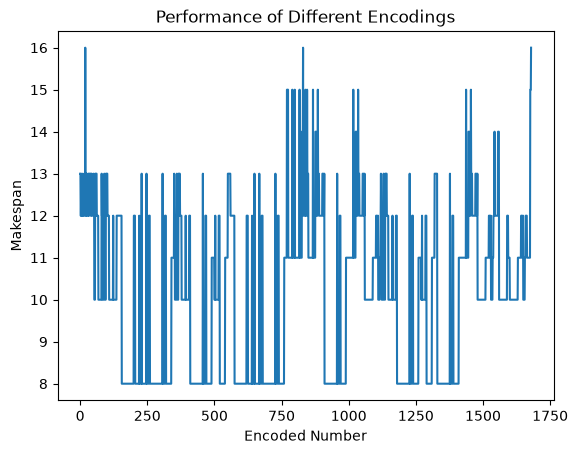


 n_jobs=3, ops_per_job=2: 
 [[0 1]
 [2 3]
 [4 5]]
Jobs array: 
 [[0, 1], [2, 3], [4, 5]]
Machine array: 
 [[3, 1], [1, 3], [2, 3]]
Time_array: 
 [3 3 2 1 1 1]
schedule: 
 [[('M3', 3), ('M1', 3)], [('M1', 2), ('M3', 1)], [('M2', 1), ('M3', 1)]]
#encoding integers: 90
Encoded number: 0, 'Decoded op:', [0, 1, 2, 3, 4, 5], 'Makespan: 10
Encoded number: 1, 'Decoded op:', [0, 1, 2, 4, 3, 5], 'Makespan: 10
Encoded number: 2, 'Decoded op:', [0, 1, 2, 4, 5, 3], 'Makespan: 9
Encoded number: 3, 'Decoded op:', [0, 1, 4, 2, 3, 5], 'Makespan: 10
Encoded number: 4, 'Decoded op:', [0, 1, 4, 2, 5, 3], 'Makespan: 9
Encoded number: 5, 'Decoded op:', [0, 1, 4, 5, 2, 3], 'Makespan: 9
Encoded number: 6, 'Decoded op:', [0, 2, 1, 3, 4, 5], 'Makespan: 6
Encoded number: 6, 'Decoded op:', [0, 2, 1, 3, 4, 5], 'Makespan: 6  <-- This is the re-indexed best sequence from max problem size
Encoded number: 7, 'Decoded op:', [0, 2, 1, 4, 3, 5], 'Makespan: 6
Encoded number: 8, 'Decoded op:', [0, 2, 1, 4, 5, 3], 'Makespa

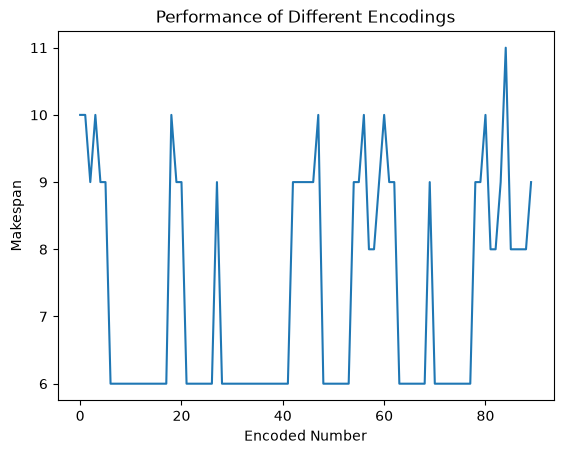


 n_jobs=2, ops_per_job=3: 
 [[0 1 2]
 [3 4 5]]
Jobs array: 
 [[0, 1, 2], [3, 4, 5]]
Machine array: 
 [[3, 1, 2], [1, 3, 3]]
Time_array: 
 [3 3 2 2 1 1]
schedule: 
 [[('M3', 3), ('M1', 3), ('M2', 2)], [('M1', 2), ('M3', 1), ('M3', 1)]]
#encoding integers: 20
Encoded number: 0, 'Decoded op:', [0, 1, 2, 3, 4, 5], 'Makespan: 10
Encoded number: 1, 'Decoded op:', [0, 1, 3, 2, 4, 5], 'Makespan: 10
Encoded number: 2, 'Decoded op:', [0, 1, 3, 4, 2, 5], 'Makespan: 10
Encoded number: 3, 'Decoded op:', [0, 1, 3, 4, 5, 2], 'Makespan: 10
Encoded number: 4, 'Decoded op:', [0, 3, 1, 2, 4, 5], 'Makespan: 8
Encoded number: 5, 'Decoded op:', [0, 3, 1, 4, 2, 5], 'Makespan: 8
Encoded number: 6, 'Decoded op:', [0, 3, 1, 4, 5, 2], 'Makespan: 8
Encoded number: 6, 'Decoded op:', [0, 3, 1, 4, 5, 2], 'Makespan: 8  <-- This is the re-indexed best sequence from max problem size
Encoded number: 7, 'Decoded op:', [0, 3, 4, 1, 2, 5], 'Makespan: 8
Encoded number: 8, 'Decoded op:', [0, 3, 4, 1, 5, 2], 'Makespan: 8
Enc

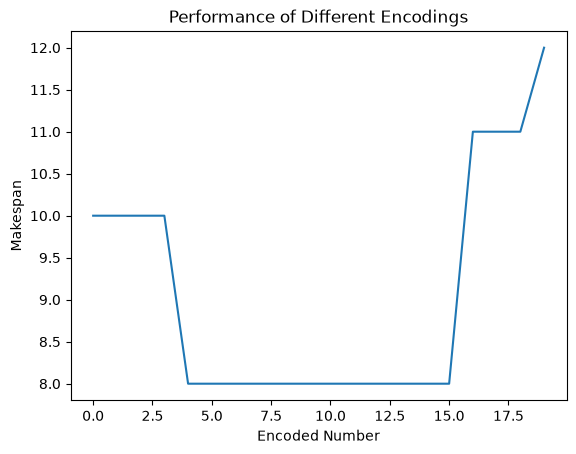


 n_jobs=2, ops_per_job=2: 
 [[0 1]
 [2 3]]
Jobs array: 
 [[0, 1], [2, 3]]
Machine array: 
 [[3, 1], [1, 3]]
Time_array: 
 [3 3 2 1]
schedule: 
 [[('M3', 3), ('M1', 3)], [('M1', 2), ('M3', 1)]]
#encoding integers: 6
Encoded number: 0, 'Decoded op:', [0, 1, 2, 3], 'Makespan: 9
Encoded number: 1, 'Decoded op:', [0, 2, 1, 3], 'Makespan: 6
Encoded number: 1, 'Decoded op:', [0, 2, 1, 3], 'Makespan: 6  <-- This is the re-indexed best sequence from max problem size
Encoded number: 2, 'Decoded op:', [0, 2, 3, 1], 'Makespan: 6
Encoded number: 3, 'Decoded op:', [2, 0, 1, 3], 'Makespan: 6
Encoded number: 4, 'Decoded op:', [2, 0, 3, 1], 'Makespan: 6
Encoded number: 5, 'Decoded op:', [2, 3, 0, 1], 'Makespan: 9
Minimum makespan found: 6
Best sequence (encoded number 1): [0, 2, 1, 3]
maxProblemSize_to_currentSize_min_decoded_ops: [0 2 1 3]


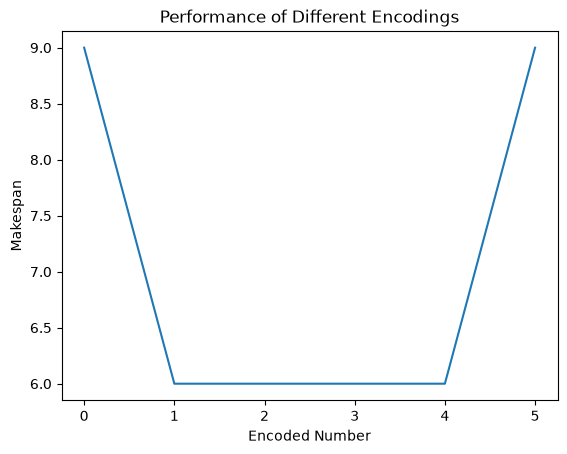

In [9]:
VARIABLE_MACHINES = True  # vary or not for each problem size
VARIABLE_TIMES = True      # vary or not for each problem size

max_jobs = 3
max_ops_in_job = 3#5


def truncate_and_reindex_random(n, m, n2, m2, seed=None, dec_ops=None):
    if seed is not None:
        np.random.seed(seed)
    # Original matrix
    original = np.arange(n * m).reshape(n, m)
    # Truncated original matrix
    truncated = original[:n2, :m2]
    # Reindexed truncated matrix
    reindexed = np.arange(n2 * m2).reshape(n2, m2)
    # Random 1D permutation of all elements
    if dec_ops is not None:
        random_array = np.array(dec_ops)
    else:
        random_array = np.random.permutation(original.ravel())
    # Build mapping: original value -> reindexed value
    mapping = dict(zip(truncated.ravel(), reindexed.ravel()))
    # Keep only values present in truncated matrix
    mask = np.isin(random_array, truncated)
    truncated_1d = random_array[mask]
    # Replace values using the mapping
    reindexed_1d = np.array([mapping[x] for x in truncated_1d])
    return (original, truncated, reindexed, random_array, truncated_1d, reindexed_1d)



for n_jobs in range(max_jobs,1,-1):   #  No of Jobs
    for ops_per_job in range(max_ops_in_job,1, -1): # Ops in Job

        Schedule_nm = np.arange(n_jobs * ops_per_job).reshape(n_jobs, ops_per_job)

        print(f'\n n_jobs={n_jobs}, ops_per_job={ops_per_job}: \n', Schedule_nm)

        #n_jobs = 3
        #ops_per_job = 3
        #Schedule_nm = np.arange(n_jobs * ops_per_job).reshape(n_jobs, ops_per_job)
        #Machine_nm = np.random.randint(1, 3+1, size=(n_jobs, ops_per_job))

        if VARIABLE_MACHINES:
            Machine_nparray = np.random.randint(1, 3+1, size=(n_jobs, ops_per_job))
            VARIABLE_MACHINES = False
        Machine_nm =  Machine_nparray[:n_jobs, :ops_per_job]


        arrays = Schedule_nm.tolist()
        Machine_arrays = Machine_nm.tolist()

        print('Jobs array: \n', arrays)
        print('Machine array: \n', Machine_arrays)

        '''
        arrays = [
            [1, 2],
            [4, 5],
            [7]
        ]
        Machine_arrays = [
            [1, 2],
            [1, 2],
            [2]
        ]
        '''

        # Time 1D-array gen-----------------------------------------------------------------------
        if VARIABLE_TIMES:
            # Initialize the recommended random generator
            rng = np.random.default_rng()
            # Generate 5 unique random integers between 10 (inclusive) and 50 (exclusive)
            n_op = np.size(arrays)
            #rnd_Time_array = rng.choice(np.arange(1, n_op + 1), size=n_op, replace=False)
            rnd_Time_array = np.random.randint(1, 3+1, size=(n_jobs, ops_per_job))
            VARIABLE_TIMES = False
        n_op = np.size(arrays)
        Time_array = rnd_Time_array[:n_jobs, :ops_per_job].reshape(-1)
        print('Time_array: \n', Time_array)

        # Machine 1D-array-----------------------------------------------------------------------
        items = []
        for arr in arrays:
            items.extend(arr)
        Machine_items = []
        for arr in Machine_arrays:
            Machine_items.extend(arr)

        # Create list of lists schedule-----------------------------------------------------------------------
        list_of_lists_schedule = []
        for i in range(len(arrays)):
            list_of_lists_schedule.append([])
        #print(list_of_lists_schedule)
        ii = 0
        for i in range(len(arrays)):
            for i2 in range(len(arrays[i])):
                list_of_lists_schedule[i].append((f"M{Machine_items[ii+i2]}", int(Time_array[ii+i2])))
            ii = ii+len(arrays[i])
        print('schedule: \n', list_of_lists_schedule)

        example_problem = make_problem( list_of_lists_schedule  )


        # Truncate and Re-index maxProblemSize_min_decoded_ops to current problem size
        if not (n_jobs == max_jobs and ops_per_job == max_ops_in_job):
            original, truncated, reindexed, random_array, truncated_1d, maxProblemSize_to_currentSize_min_decoded_ops = \
            truncate_and_reindex_random(max_jobs, max_ops_in_job, n_jobs, ops_per_job, seed=42, dec_ops=maxProblemSize_min_decoded_ops)



        # save minimum makespan and corresponding sequence for each problem size-------------------------------
        # print decoded operation ids and makespan for each encoding number
        print('#encoding integers:', total_encoding_count(example_problem))
        Makespan_list = []
        min_time = 1000000
        min_decoded_ops = None
        all_decoded_ops = []
        for encoded_number in range(total_encoding_count(example_problem)):
            sequence = decode_integer(encoded_number, example_problem)
            cost = makespan(sequence)
            Makespan_list.append(cost)
            if cost < min_time:
                min_time = cost
                min_encoded_number = encoded_number
                min_decoded_ops = [operation.op_id for operation, option in sequence]
            if n_op < 10:
                all_decoded_ops.append([operation.op_id for operation, option in sequence])
                print(f"Encoded number: {encoded_number}, 'Decoded op:', {[operation.op_id for operation, option in sequence]}, 'Makespan: {cost}")
            if not (n_jobs == max_jobs and ops_per_job == max_ops_in_job):
                if all(maxProblemSize_to_currentSize_min_decoded_ops == [operation.op_id for operation, option in sequence]):
                    print(f"Encoded number: {encoded_number}, 'Decoded op:', {[operation.op_id for operation, option in sequence]}, 'Makespan: {cost}  <-- This is the re-indexed best sequence from max problem size")
        print(f"Minimum makespan found: {min_time}")
        print(f"Best sequence (encoded number {min_encoded_number}): {min_decoded_ops}")
        

        if n_jobs == max_jobs and ops_per_job == max_ops_in_job:
            maxProblemSize_min_decoded_ops = min_decoded_ops.copy()
            maxProblemSize_to_currentSize_min_decoded_ops = maxProblemSize_min_decoded_ops.copy()

        print('maxProblemSize_to_currentSize_min_decoded_ops:', maxProblemSize_to_currentSize_min_decoded_ops)

        # plot makespan vs encoded number
        plt.plot(range(total_encoding_count(example_problem)), Makespan_list)
        plt.xlabel("Encoded Number")
        plt.ylabel("Makespan")
        plt.title("Performance of Different Encodings")
        plt.show()

        # save min makespan and corresponding sequence for each problem size
        encoding_integers_5, Makespan_list_5 = range(total_encoding_count(example_problem)), Makespan_list
        min_encoded_number_5 = min_encoded_number
        min_decoded_ops_5 = min_decoded_ops
        total_encodings_5 = total_encoding_count(example_problem)
        if n_op < 10:
            all_decoded_ops_5 = all_decoded_ops
        maxProblemSize_to_currentSize_min_decoded_ops_5 = maxProblemSize_to_currentSize_min_decoded_ops

In [10]:
[operation.op_id for operation, option in sequence]

[2, 3, 0, 1]

In [11]:
maxProblemSize_to_currentSize_min_decoded_ops

array([0, 2, 1, 3])

In [12]:
is_equal = maxProblemSize_to_currentSize_min_decoded_ops == [operation.op_id for operation, option in sequence]
all(is_equal)

False

### Problem Size (min to max)


 n_jobs=3, ops_per_job=2: 
 [[0 1]
 [2 3]
 [4 5]]
Jobs array: 
 [[0, 1], [2, 3], [4, 5]]
Machine array: 
 [[2, 1], [1, 2], [2, 2]]
Time_array: 
 [1 4 2 4 4 4]
schedule: 
 [[('M2', 1), ('M1', 4)], [('M1', 2), ('M2', 4)], [('M2', 4), ('M2', 4)]]
#encoding integers: 90
Encoded number: 0, 'Decoded op:', [0, 1, 2, 3, 4, 5], 'Makespan: 19
Encoded number: 1, 'Decoded op:', [0, 1, 2, 4, 3, 5], 'Makespan: 15
Encoded number: 2, 'Decoded op:', [0, 1, 2, 4, 5, 3], 'Makespan: 13
Encoded number: 3, 'Decoded op:', [0, 1, 4, 2, 3, 5], 'Makespan: 15
Encoded number: 4, 'Decoded op:', [0, 1, 4, 2, 5, 3], 'Makespan: 13
Encoded number: 5, 'Decoded op:', [0, 1, 4, 5, 2, 3], 'Makespan: 13
Encoded number: 6, 'Decoded op:', [0, 2, 1, 3, 4, 5], 'Makespan: 14
Encoded number: 7, 'Decoded op:', [0, 2, 1, 4, 3, 5], 'Makespan: 13
Encoded number: 8, 'Decoded op:', [0, 2, 1, 4, 5, 3], 'Makespan: 13
Encoded number: 9, 'Decoded op:', [0, 2, 3, 1, 4, 5], 'Makespan: 14
Encoded number: 10, 'Decoded op:', [0, 2, 3, 4, 1, 5

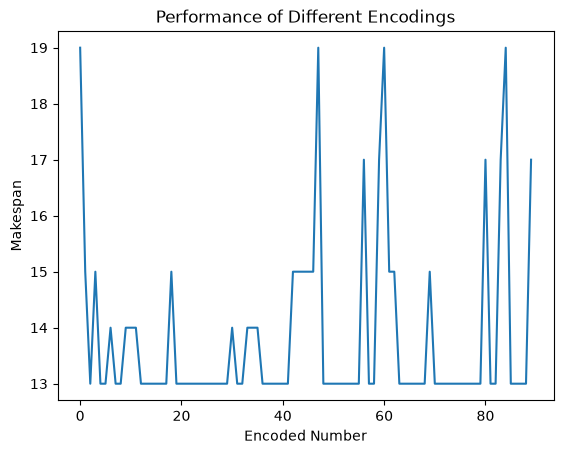


 n_jobs=3, ops_per_job=5: 
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
Jobs array: 
 [[0, 1, 2, 3, 4], [5, 6, 7, 8, 9], [10, 11, 12, 13, 14]]
Machine array: 
 [[2, 1, 2, 1, 1], [1, 2, 2, 2, 2], [2, 2, 2, 2, 2]]
Time_array: 
 [1 4 2 4 4 2 4 2 4 2 4 4 1 1 4]
schedule: 
 [[('M2', 1), ('M1', 4), ('M2', 2), ('M1', 4), ('M1', 4)], [('M1', 2), ('M2', 4), ('M2', 2), ('M2', 4), ('M2', 2)], [('M2', 4), ('M2', 4), ('M2', 1), ('M2', 1), ('M2', 4)]]


,enc_no,dec_ops,cost
0,2,"[0, 1, 5, 10, 11, 6]",13
1,4,"[0, 1, 10, 5, 11, 6]",13
2,5,"[0, 1, 10, 11, 5, 6]",13
3,7,"[0, 5, 1, 10, 6, 11]",13
4,8,"[0, 5, 1, 10, 11, 6]",13
...,...,...,...
85,89,"[10, 11, 5, 6, 0, 1]",17
86,0,"[0, 1, 5, 6, 10, 11]",19
87,47,"[5, 6, 10, 11, 0, 1]",19
88,60,"[10, 0, 1, 5, 6, 11]",19


#encoding integers: 756756
#EncIntegers: 756756, #Unmatch: 0  #Match: 756756 = #Exact: 151200 + #Order: 605556
Minimum makespan found: 29
Best sequence (encoded number 32802): [0, 1, 5, 10, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14]
minProblemSize_to_currentSize_min_decoded_ops: [0, 1, 5, 10, 11, 6]


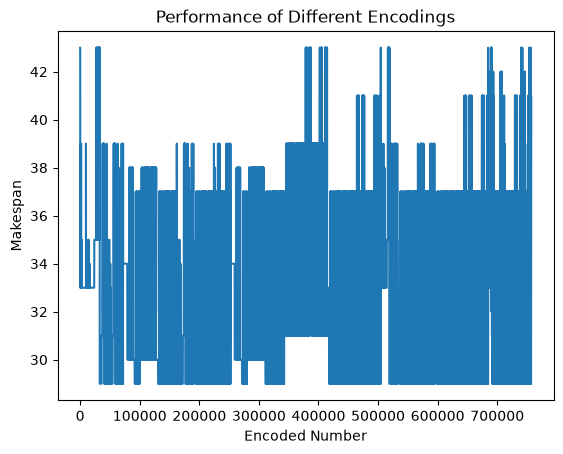

{np.int64(13): {29: 85560, 30: 5580, 31: 6572, 32: 1488, 33: 1860, 35: 1860, 37: 1240}, np.int64(14): {30: 11040, 31: 720, 32: 848, 33: 192, 34: 240, 36: 240, 38: 160}, np.int64(15): {31: 15180, 32: 990, 33: 1166, 34: 264, 35: 330, 37: 330, 39: 220}, np.int64(17): {29: 800, 30: 1350, 31: 1880, 32: 1170, 33: 2950, 35: 150, 37: 100}, np.int64(19): {31: 160, 32: 270, 33: 376, 34: 234, 35: 4730, 36: 270, 37: 348, 38: 72, 39: 110, 41: 90, 43: 60}}
{np.int64(13): {29: 197420, 30: 30726, 31: 30697, 32: 10191, 33: 39305, 34: 9104, 35: 10782, 37: 6821, 38: 184, 39: 126}, np.int64(14): {30: 47760, 31: 3480, 32: 4008, 33: 1728, 34: 7810, 36: 894, 38: 960}, np.int64(15): {29: 22495, 30: 2682, 31: 31216, 32: 4554, 33: 18719, 34: 3570, 35: 11060, 36: 108, 37: 1298, 38: 288, 39: 1646}, np.int64(17): {29: 3490, 30: 7800, 31: 13668, 32: 5838, 33: 12146, 34: 2100, 35: 6374, 36: 432, 37: 4327, 39: 525, 41: 196}, np.int64(19): {29: 520, 30: 60, 31: 1910, 32: 4611, 33: 17055, 34: 3174, 35: 13616, 36: 1422,

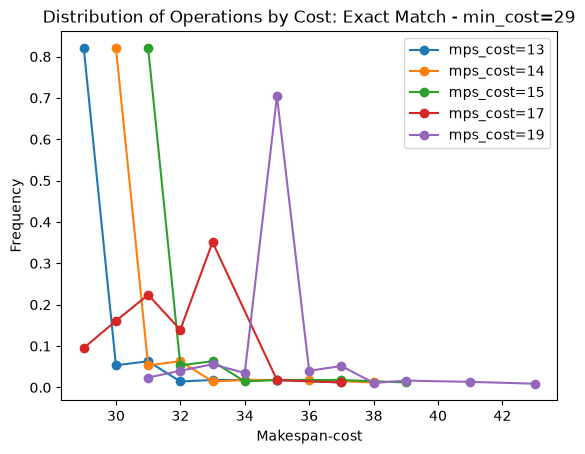

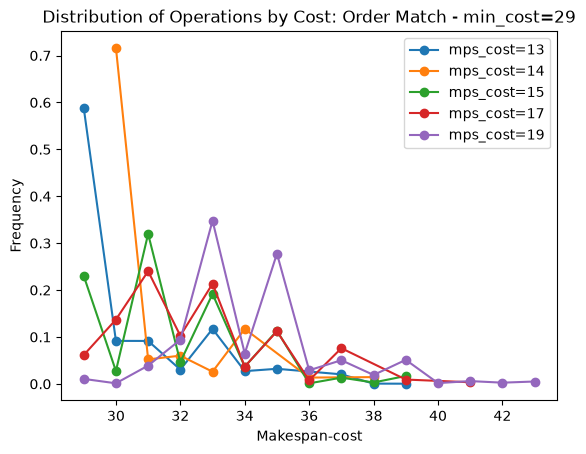

In [67]:
VARIABLE_MACHINES = True  # vary or not for each problem size
VARIABLE_TIMES = True      # vary or not for each problem size

min_jobs = 3;       max_jobs = 3;       step_jobs = 1
min_ops_in_job = 2; max_ops_in_job = 5; step_ops = 3


# minProblemSize decoded ops  to  currProblemSize decoded ops mapping
def minProblemSize_to_currProblemSize_decoded_ops_fn(min_jobs, min_ops_in_job, curr_jobs, curr_ops_in_job, minProblemSize_decoded_ops):
    minProblemSize_to_currProblemSize_decoded_ops = minProblemSize_decoded_ops.copy()
    for i in range(len(minProblemSize_decoded_ops)):
        for m in range(min_jobs):
            if minProblemSize_decoded_ops[i] >= m*min_ops_in_job and minProblemSize_decoded_ops[i] < (m+1)*min_ops_in_job:
                minProblemSize_to_currProblemSize_decoded_ops[i] += m*(curr_ops_in_job - min_ops_in_job)
    return minProblemSize_to_currProblemSize_decoded_ops



if VARIABLE_MACHINES:
    Machine_nparray = np.random.randint(1, 2+1, size=(max_jobs, max_ops_in_job))
    VARIABLE_MACHINES = False

# Time 1D-array gen-----------------------------------------------------------------------
if VARIABLE_TIMES:
    # Initialize the recommended random generator
    rng = np.random.default_rng()
    # Generate 5 unique random integers between 10 (inclusive) and 50 (exclusive)
    n_op = max_jobs * max_ops_in_job
    #rnd_Time_array = rng.choice(np.arange(1, n_op + 1), size=n_op, replace=False)
    rnd_Time_array = np.random.randint(1, 4+1, size=(max_jobs, max_ops_in_job))
    VARIABLE_TIMES = False


minProblemSize_min_decoded_ops = None 

for n_jobs in range(min_jobs, max_jobs+1, step_jobs):   #  No of Jobs
    for ops_per_job in range(min_ops_in_job, max_ops_in_job+1, step_ops): # Ops in Job

        Schedule_nm = np.arange(n_jobs * ops_per_job).reshape(n_jobs, ops_per_job)

        print(f'\n n_jobs={n_jobs}, ops_per_job={ops_per_job}: \n', Schedule_nm)

        #n_jobs = 3
        #ops_per_job = 3
        #Schedule_nm = np.arange(n_jobs * ops_per_job).reshape(n_jobs, ops_per_job)
        #Machine_nm = np.random.randint(1, 3+1, size=(n_jobs, ops_per_job))

        is_min_problem_size = (n_jobs == min_jobs and ops_per_job == min_ops_in_job)

        if VARIABLE_MACHINES:
            Machine_nparray = np.random.randint(1, 3+1, size=(n_jobs, ops_per_job))
            VARIABLE_MACHINES = False
        Machine_nm =  Machine_nparray[:n_jobs, :ops_per_job]


        arrays = Schedule_nm.tolist()
        Machine_arrays = Machine_nm.tolist()

        print('Jobs array: \n', arrays)
        print('Machine array: \n', Machine_arrays)

        '''
        arrays = [
            [1, 2],
            [4, 5],
            [7]
        ]
        Machine_arrays = [
            [1, 2],
            [1, 2],
            [2]
        ]
        '''

        # Time 1D-array gen-----------------------------------------------------------------------
        if VARIABLE_TIMES:
            # Initialize the recommended random generator
            rng = np.random.default_rng()
            # Generate 5 unique random integers between 10 (inclusive) and 50 (exclusive)
            n_op = np.size(arrays)
            #rnd_Time_array = rng.choice(np.arange(1, n_op + 1), size=n_op, replace=False)
            rnd_Time_array = np.random.randint(1, 3+1, size=(n_jobs, ops_per_job))
            VARIABLE_TIMES = False
        n_op = np.size(arrays)
        Time_array = rnd_Time_array[:n_jobs, :ops_per_job].reshape(-1)
        print('Time_array: \n', Time_array)

        # Machine 1D-array-----------------------------------------------------------------------
        items = []
        for arr in arrays:
            items.extend(arr)
        Machine_items = []
        for arr in Machine_arrays:
            Machine_items.extend(arr)

        # Create list of lists schedule-----------------------------------------------------------------------
        list_of_lists_schedule = []
        for i in range(len(arrays)):
            list_of_lists_schedule.append([])
        #print(list_of_lists_schedule)
        ii = 0
        for i in range(len(arrays)):
            for i2 in range(len(arrays[i])):
                list_of_lists_schedule[i].append((f"M{Machine_items[ii+i2]}", int(Time_array[ii+i2])))
            ii = ii+len(arrays[i])
        print('schedule: \n', list_of_lists_schedule)

        example_problem = make_problem( list_of_lists_schedule  )

        # minProblemSize_decoded_ops to current problem size---------------------------------------------------
        # create dictionary of dictionaries - useful for distributions(distribution(costs))--------------------
        if not  is_min_problem_size:
            minProblemSize_to_currentSize_min_decoded_ops = minProblemSize_to_currProblemSize_decoded_ops_fn(min_jobs, min_ops_in_job, n_jobs, ops_per_job, minProblemSize_min_decoded_ops)
            df_mps_to_cps = df.copy()
            for cost_mps in cost_unique_mps:
                dec_ops_sublist = df[df['cost'] == cost_mps]['dec_ops'].values
                dec_ops_sublist_to_curr_problemsize = []
                for ops in dec_ops_sublist:
                    minProblemSize_to_currProblemSize_dec_ops = minProblemSize_to_currProblemSize_decoded_ops_fn(min_jobs, min_ops_in_job, n_jobs, ops_per_job, ops)
                    dec_ops_sublist_to_curr_problemsize.append(minProblemSize_to_currProblemSize_dec_ops)
                mask = df_mps_to_cps['cost'] == cost_mps
                # Force a clean 1D array of lists, matching the mask row count
                array_of_lists = np.empty(len(dec_ops_sublist_to_curr_problemsize), dtype=object)
                for i, lst in enumerate(dec_ops_sublist_to_curr_problemsize):
                    array_of_lists[i] = lst
                # Assign without any slicing [:, 0]
                df_mps_to_cps.loc[mask, 'dec_ops'] = array_of_lists

            display(df_mps_to_cps)

            # create dictionary of dictionaries - useful for distributions(distribution(costs))--------------------
            # Initialize outer dictionary
            distributions_exact_match = {k: {} for k in cost_unique_mps}
            distributions_order_match = {k: {} for k in cost_unique_mps}
            # Group values by key
            grouped_exact_match = {}
            grouped_order_match = {}
                                        

        # save minimum makespan and corresponding sequence-----------------------------------------------------
        # print decoded operation ids and makespan for each encoding number
        n_exact_match = 0
        n_order_match = 0
        n_unmatch = 0
        n_encoding_integers = total_encoding_count(example_problem)
        print('#encoding integers:', n_encoding_integers)
        Makespan_list = []
        min_time = 1000000
        min_decoded_ops = None
        all_decoded_ops = []
        encNo_decOps_cost_list = []
        for encoded_number in range(total_encoding_count(example_problem)):
            go_to_next_enc_int = 0
            sequence = decode_integer(encoded_number, example_problem)
            decoded_ops = [operation.op_id for operation, option in sequence]
            cost = makespan(sequence)
            Makespan_list.append(cost)
            encNo_decOps_cost_list.append((encoded_number, decoded_ops, cost))
            if n_op < 10:
                all_decoded_ops.append(decoded_ops)
                print(f"Encoded number: {encoded_number}, 'Decoded op:', {decoded_ops}, 'Makespan: {cost}")
            # minProblemSize_decoded_ops to current problem size--------------------------------------------------
            if not  is_min_problem_size:
                for cost_mps in cost_unique_mps:
                    dec_ops_sublist_to_curr_problemsize = df_mps_to_cps[df_mps_to_cps['cost'] == cost_mps]['dec_ops'].values
                    for ops in dec_ops_sublist_to_curr_problemsize:
                        exact_match = (ops == decoded_ops[:len(ops)])
                        order_match = False
                        if exact_match:
                            #print(f"Encoded number: {encoded_number}, 'Decoded op:', {decoded_ops}, 'Makespan: {cost}  <-- mps_to_cps_ops: {ops}, cost_mps: {cost_mps} EXACT----")
                            n_exact_match += 1
                            grouped_exact_match.setdefault(cost_mps, []).append(cost)
                            go_to_next_enc_int = 1
                            break
                        elif ops[0] == decoded_ops[0]:
                            i_dec = 1
                            for ele in ops[1:]:
                                for ele2 in decoded_ops[i_dec:]:
                                    i_dec += 1
                                    if ele == ele2:
                                        if ele == ops[-1]:
                                            order_match = True
                                        break      
                            if order_match:
                                #print(f"Encoded number: {encoded_number}, 'Decoded op:', {decoded_ops}, 'Makespan: {cost}  <-- mps_to_cps_ops: {ops}, cost_mps: {cost_mps} ORDER")
                                n_order_match +=1
                                grouped_order_match.setdefault(cost_mps, []).append(cost)
                                go_to_next_enc_int = 1
                                break
                    if  go_to_next_enc_int == 1:
                        break

            if go_to_next_enc_int == 0:
                n_unmatch += 1
                
            if cost < min_time:
                min_time = cost
                min_encoded_number = encoded_number
                min_decoded_ops = decoded_ops.copy()
            
        print(f'#EncIntegers: {n_encoding_integers}, #Unmatch: {n_unmatch}  #Match: {n_exact_match + n_order_match} = #Exact: {n_exact_match} + #Order: {n_order_match}')
        print(f"Minimum makespan found: {min_time}")
        print(f"Best sequence (encoded number {min_encoded_number}): {min_decoded_ops}")
        
        # save min_decoded_ops, encNo_deoOps_cost_list_sortedByCost for min problem size
        if is_min_problem_size:
            minProblemSize_min_decoded_ops = min_decoded_ops.copy()
            minProblemSize_to_currentSize_min_decoded_ops = minProblemSize_min_decoded_ops.copy()
            
            encNo_decOps_cost_list_sortedByCost = sorted(encNo_decOps_cost_list, key=lambda x: x[2])
            cost_list = [x[2] for x in encNo_decOps_cost_list_sortedByCost]
            min_cost = min(cost_list)
            max_cost = max(cost_list)
            cost_unique_mps, cost_counts_mps = np.unique(cost_list, return_counts=True)
            df = pd.DataFrame({
                'enc_no': [x[0] for x in encNo_decOps_cost_list_sortedByCost],
                'dec_ops': [x[1] for x in encNo_decOps_cost_list_sortedByCost],
                'cost': [x[2] for x in encNo_decOps_cost_list_sortedByCost]
            })

        print('minProblemSize_to_currentSize_min_decoded_ops:', minProblemSize_to_currentSize_min_decoded_ops)

        # plot makespan vs encoded number
        plt.plot(range(total_encoding_count(example_problem)), Makespan_list)
        plt.xlabel("Encoded Number")
        plt.ylabel("Makespan")
        plt.title("Performance of Different Encodings")
        plt.show()

        if not is_min_problem_size:
            # distributions(distribution(costs)) for exact match and order match--------------------------------------------
            # Compute distribution (frequency) for each key
            for key, values in grouped_exact_match.items():
                distributions_exact_match[key] = dict(sorted(dict(Counter(values)).items()))
            for key, values in grouped_order_match.items():
                distributions_order_match[key] = dict(sorted(dict(Counter(values)).items()))
            print(distributions_exact_match)
            print(distributions_order_match)

            for mps_key, distribution in distributions_exact_match.items():
                total = sum(distribution.values())
                for key in distribution:
                    distribution[key] /= total  # Normalize to get frequency
                plt.plot(distribution.keys(), distribution.values(), marker='o', label=f'mps_cost={mps_key}')
                plt.legend()
            plt.xlabel('Makespan-cost')
            plt.ylabel('Frequency')
            plt.title(f'Distribution of Operations by Cost: Exact Match - min_cost={min_time}')
            plt.show()
            for mps_key, distribution in distributions_order_match.items():
                total = sum(distribution.values())
                for key in distribution:
                    distribution[key] /= total  # Normalize to get frequency
                plt.plot(distribution.keys(), distribution.values(), marker='o', label=f'mps_cost={mps_key}')
                plt.legend()
            plt.xlabel('Makespan-cost')
            plt.ylabel('Frequency')
            plt.title(f'Distribution of Operations by Cost: Order Match - min_cost={min_time}')
            plt.show()


### Temp

In [20]:
encNo_decOps_cost_list[0][0], encNo_decOps_cost_list[0][1], encNo_decOps_cost_list[0][2]

(0, [0, 1, 2, 3, 4, 5, 6, 7, 8], 27)

In [21]:
encNo_decOps_cost_list

[(0, [0, 1, 2, 3, 4, 5, 6, 7, 8], 27),
 (1, [0, 1, 2, 3, 4, 6, 5, 7, 8], 27),
 (2, [0, 1, 2, 3, 4, 6, 7, 5, 8], 24),
 (3, [0, 1, 2, 3, 4, 6, 7, 8, 5], 24),
 (4, [0, 1, 2, 3, 6, 4, 5, 7, 8], 27),
 (5, [0, 1, 2, 3, 6, 4, 7, 5, 8], 24),
 (6, [0, 1, 2, 3, 6, 4, 7, 8, 5], 24),
 (7, [0, 1, 2, 3, 6, 7, 4, 5, 8], 23),
 (8, [0, 1, 2, 3, 6, 7, 4, 8, 5], 23),
 (9, [0, 1, 2, 3, 6, 7, 8, 4, 5], 23),
 (10, [0, 1, 2, 6, 3, 4, 5, 7, 8], 27),
 (11, [0, 1, 2, 6, 3, 4, 7, 5, 8], 24),
 (12, [0, 1, 2, 6, 3, 4, 7, 8, 5], 24),
 (13, [0, 1, 2, 6, 3, 7, 4, 5, 8], 23),
 (14, [0, 1, 2, 6, 3, 7, 4, 8, 5], 23),
 (15, [0, 1, 2, 6, 3, 7, 8, 4, 5], 23),
 (16, [0, 1, 2, 6, 7, 3, 4, 5, 8], 23),
 (17, [0, 1, 2, 6, 7, 3, 4, 8, 5], 23),
 (18, [0, 1, 2, 6, 7, 3, 8, 4, 5], 23),
 (19, [0, 1, 2, 6, 7, 8, 3, 4, 5], 23),
 (20, [0, 1, 3, 2, 4, 5, 6, 7, 8], 27),
 (21, [0, 1, 3, 2, 4, 6, 5, 7, 8], 27),
 (22, [0, 1, 3, 2, 4, 6, 7, 5, 8], 24),
 (23, [0, 1, 3, 2, 4, 6, 7, 8, 5], 24),
 (24, [0, 1, 3, 2, 6, 4, 5, 7, 8], 27),
 (25, [0, 

[(1330, [6, 3, 0, 1, 2, 4, 5, 7, 8], 27),
 (1336, [6, 3, 0, 1, 4, 2, 5, 7, 8], 27),
 (1339, [6, 3, 0, 1, 4, 5, 2, 7, 8], 27),
 (1360, [6, 3, 0, 4, 1, 2, 5, 7, 8], 27),
 (1363, [6, 3, 0, 4, 1, 5, 2, 7, 8], 27),
 (1372, [6, 3, 0, 4, 5, 1, 2, 7, 8], 27),
 (1420, [6, 3, 4, 0, 1, 2, 5, 7, 8], 27),
 (1423, [6, 3, 4, 0, 1, 5, 2, 7, 8], 27),
 (1432, [6, 3, 4, 0, 5, 1, 2, 7, 8], 27),
 (1450, [6, 3, 4, 5, 0, 1, 2, 7, 8], 27)]

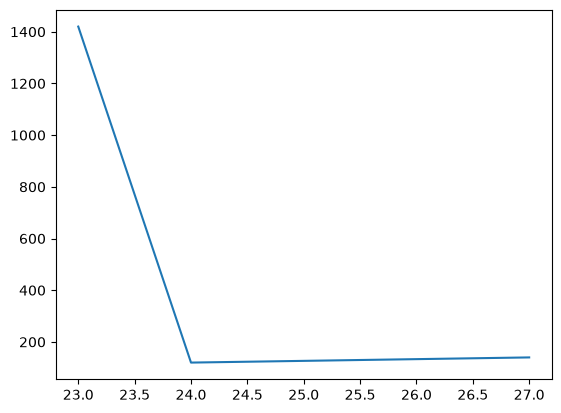

In [22]:
encNo_decOps_cost_list_sortedByCost = sorted(encNo_decOps_cost_list, key=lambda x: x[2])
cost_list = [x[2] for x in encNo_decOps_cost_list_sortedByCost]
min_cost = min(cost_list)
max_cost = max(cost_list)
cost_unique, cost_counts = np.unique(cost_list, return_counts=True)

plt.plot(cost_unique, cost_counts)

encNo_decOps_cost_list
encNo_decOps_cost_list_sortedByCost[-10:]

In [23]:
dictCost_encNo_decOps = {x[2]: (x[0], x[1]) for x in encNo_decOps_cost_list}

dictCost_encNo_decOps

{27: (1450, [6, 3, 4, 5, 0, 1, 2, 7, 8]),
 24: (1422, [6, 3, 4, 0, 1, 2, 7, 8, 5]),
 23: (1679, [6, 7, 8, 3, 4, 5, 0, 1, 2])}

In [24]:
encNo_decOps_cost_list_sortedByCost = sorted(encNo_decOps_cost_list, key=lambda x: x[2])
cost_list = [x[2] for x in encNo_decOps_cost_list_sortedByCost]
min_cost = min(cost_list)
max_cost = max(cost_list)
cost_unique, cost_counts = np.unique(cost_list, return_counts=True)

df = pd.DataFrame({
    'enc_no': [x[0] for x in encNo_decOps_cost_list_sortedByCost],
    'dec_ops': [x[1] for x in encNo_decOps_cost_list_sortedByCost],
    'cost': [x[2] for x in encNo_decOps_cost_list_sortedByCost]
})

df

,enc_no,dec_ops,cost
0,7,"[0, 1, 2, 3, 6, 7, 4, 5, 8]",23
1,8,"[0, 1, 2, 3, 6, 7, 4, 8, 5]",23
2,9,"[0, 1, 2, 3, 6, 7, 8, 4, 5]",23
3,13,"[0, 1, 2, 6, 3, 7, 4, 5, 8]",23
4,14,"[0, 1, 2, 6, 3, 7, 4, 8, 5]",23
...,...,...,...
1675,1372,"[6, 3, 0, 4, 5, 1, 2, 7, 8]",27
1676,1420,"[6, 3, 4, 0, 1, 2, 5, 7, 8]",27
1677,1423,"[6, 3, 4, 0, 1, 5, 2, 7, 8]",27
1678,1432,"[6, 3, 4, 0, 5, 1, 2, 7, 8]",27


In [25]:
for cost in cost_unique:
    display(df[df['cost'] == cost]['dec_ops'].values)

array([list([0, 1, 2, 3, 6, 7, 4, 5, 8]),
       list([0, 1, 2, 3, 6, 7, 4, 8, 5]),
       list([0, 1, 2, 3, 6, 7, 8, 4, 5]), ...,
       list([6, 7, 8, 3, 4, 0, 1, 5, 2]),
       list([6, 7, 8, 3, 4, 0, 5, 1, 2]),
       list([6, 7, 8, 3, 4, 5, 0, 1, 2])], shape=(1420,), dtype=object)

array([list([0, 1, 2, 3, 4, 6, 7, 5, 8]),
       list([0, 1, 2, 3, 4, 6, 7, 8, 5]),
       list([0, 1, 2, 3, 6, 4, 7, 5, 8]),
       list([0, 1, 2, 3, 6, 4, 7, 8, 5]),
       list([0, 1, 2, 6, 3, 4, 7, 5, 8]),
       list([0, 1, 2, 6, 3, 4, 7, 8, 5]),
       list([0, 1, 3, 2, 4, 6, 7, 5, 8]),
       list([0, 1, 3, 2, 4, 6, 7, 8, 5]),
       list([0, 1, 3, 2, 6, 4, 7, 5, 8]),
       list([0, 1, 3, 2, 6, 4, 7, 8, 5]),
       list([0, 1, 3, 4, 2, 6, 7, 5, 8]),
       list([0, 1, 3, 4, 2, 6, 7, 8, 5]),
       list([0, 1, 3, 4, 6, 2, 7, 5, 8]),
       list([0, 1, 3, 4, 6, 2, 7, 8, 5]),
       list([0, 1, 3, 6, 2, 4, 7, 5, 8]),
       list([0, 1, 3, 6, 2, 4, 7, 8, 5]),
       list([0, 1, 3, 6, 4, 2, 7, 5, 8]),
       list([0, 1, 3, 6, 4, 2, 7, 8, 5]),
       list([0, 1, 6, 2, 3, 4, 7, 5, 8]),
       list([0, 1, 6, 2, 3, 4, 7, 8, 5]),
       list([0, 1, 6, 3, 2, 4, 7, 5, 8]),
       list([0, 1, 6, 3, 2, 4, 7, 8, 5]),
       list([0, 1, 6, 3, 4, 2, 7, 5, 8]),
       list([0, 1, 6, 3, 4, 2, 7, 

array([list([0, 1, 2, 3, 4, 5, 6, 7, 8]),
       list([0, 1, 2, 3, 4, 6, 5, 7, 8]),
       list([0, 1, 2, 3, 6, 4, 5, 7, 8]),
       list([0, 1, 2, 6, 3, 4, 5, 7, 8]),
       list([0, 1, 3, 2, 4, 5, 6, 7, 8]),
       list([0, 1, 3, 2, 4, 6, 5, 7, 8]),
       list([0, 1, 3, 2, 6, 4, 5, 7, 8]),
       list([0, 1, 3, 4, 2, 5, 6, 7, 8]),
       list([0, 1, 3, 4, 2, 6, 5, 7, 8]),
       list([0, 1, 3, 4, 5, 2, 6, 7, 8]),
       list([0, 1, 3, 4, 5, 6, 2, 7, 8]),
       list([0, 1, 3, 4, 6, 2, 5, 7, 8]),
       list([0, 1, 3, 4, 6, 5, 2, 7, 8]),
       list([0, 1, 3, 6, 2, 4, 5, 7, 8]),
       list([0, 1, 3, 6, 4, 2, 5, 7, 8]),
       list([0, 1, 3, 6, 4, 5, 2, 7, 8]),
       list([0, 1, 6, 2, 3, 4, 5, 7, 8]),
       list([0, 1, 6, 3, 2, 4, 5, 7, 8]),
       list([0, 1, 6, 3, 4, 2, 5, 7, 8]),
       list([0, 1, 6, 3, 4, 5, 2, 7, 8]),
       list([0, 3, 1, 2, 4, 5, 6, 7, 8]),
       list([0, 3, 1, 2, 4, 6, 5, 7, 8]),
       list([0, 3, 1, 2, 6, 4, 5, 7, 8]),
       list([0, 3, 1, 4, 2, 5, 6, 

### distance

12 23


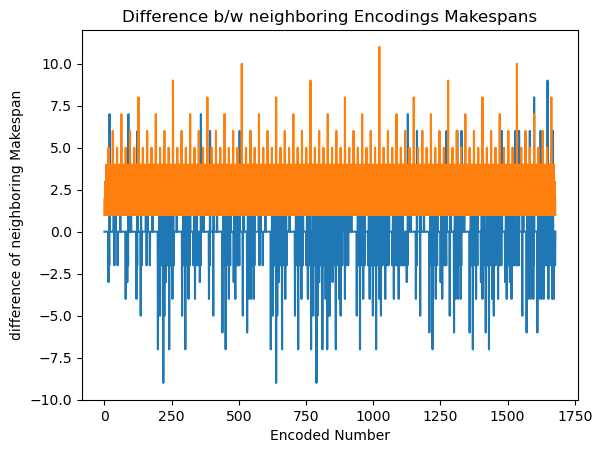

In [ ]:
def hamming_distance(x: int, y: int) -> int:
    return bin(x ^ y).count('1')

hamming_distances = [hamming_distance(x, y) for x, y in [(i,i+1) for i in range(len(Makespan_list)-1)]]

print(min(Makespan_list), max(Makespan_list))
plt.plot( np.array(Makespan_list[:-1])-np.array(Makespan_list[1:]))
plt.plot(hamming_distances)
plt.xlabel("Encoded Number")
plt.ylabel("difference of neighboring Makespan")
plt.title("Difference b/w neighboring Encodings Makespans")
plt.show()


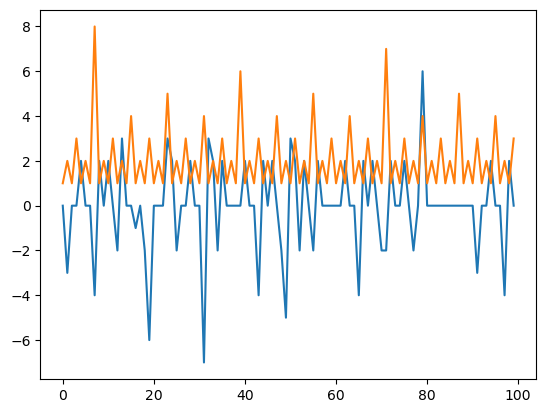

In [ ]:
n_samples = 100
n_begin = 1400
n_end = n_begin+n_samples
plt.plot( (np.array(Makespan_list[:-1])-np.array(Makespan_list[1:]))[n_begin:n_end])
plt.plot(hamming_distances[n_begin:n_end])

In [ ]:
sequence

((Operation(op_id=6, job_id=2, step_id=0, options=(MachineOption(machine='M1', duration=2),)),
  MachineOption(machine='M1', duration=2)),
 (Operation(op_id=7, job_id=2, step_id=1, options=(MachineOption(machine='M1', duration=3),)),
  MachineOption(machine='M1', duration=3)),
 (Operation(op_id=8, job_id=2, step_id=2, options=(MachineOption(machine='M1', duration=2),)),
  MachineOption(machine='M1', duration=2)),
 (Operation(op_id=3, job_id=1, step_id=0, options=(MachineOption(machine='M1', duration=2),)),
  MachineOption(machine='M1', duration=2)),
 (Operation(op_id=4, job_id=1, step_id=1, options=(MachineOption(machine='M2', duration=3),)),
  MachineOption(machine='M2', duration=3)),
 (Operation(op_id=5, job_id=1, step_id=2, options=(MachineOption(machine='M2', duration=2),)),
  MachineOption(machine='M2', duration=2)),
 (Operation(op_id=0, job_id=0, step_id=0, options=(MachineOption(machine='M2', duration=3),)),
  MachineOption(machine='M2', duration=3)),
 (Operation(op_id=1, job_id

## Experiment

### configuraton

In [ ]:
# configuration

Time_variation = 1


### Problem generation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
from collections import Counter

arrays = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]
Machine_arrays = [
    [1, 2, 1],
    [1, 2, 2],
    [2, 1, 2]
]
'''
arrays = [
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
]
Machine_arrays = [
    [1, 2, 1, 2],
    [1, 2, 2, 1],
    [2, 1, 2, 1]
]
arrays = [
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15]
]
Machine_arrays = [
    [1, 2, 1, 2, 1],
    [1, 2, 2, 1, 2],
    [2, 1, 2, 1, 2]
]

arrays = [
    [1, 2],
    [4, 5],
    [7, 8]
]
Machine_arrays = [
    [1, 2],
    [1, 2],
    [2, 1]
]

arrays = [
    [1, 2],
    [3, 4]
]
Machine_arrays = [
    [1, 2],
    [1, 2]
]
'''

if Time_variation:
    # Initialize the recommended random generator
    rng = np.random.default_rng()
    # Generate 5 unique random integers between 10 (inclusive) and 50 (exclusive)
    n_op = np.size(arrays)
    rnd_Time_array = rng.choice(np.arange(1, n_op + 1), size=n_op, replace=False)

n_op = np.size(arrays)
Time_array = rnd_Time_array
if n_op == 9:
    #Time_array = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
    Time_array = rnd_Time_array
elif n_op == 6:
    #Time_array = np.array([1, 2, 4, 5, 7, 8])
    Time_array = [int(rnd_Time_array[i]) for i in [0,1,3,4,6,7]]

print('Time_array:', Time_array)


items = []
for arr in arrays:
    items.extend(arr)
Machine_items = []
for arr in Machine_arrays:
    Machine_items.extend(arr)


list_of_lists_schedule = []
for i in range(len(arrays)):
    list_of_lists_schedule.append([])
#print(list_of_lists_schedule)
ii = 0
for i in range(len(arrays)):
    for i2 in range(len(arrays[i])):
        list_of_lists_schedule[i].append((f"M{Machine_items[ii+i2]}", int(Time_array[ii+i2])))
    ii = ii+len(arrays[i])
print(list_of_lists_schedule)



example_problem = make_problem( list_of_lists_schedule  )

#----------------------------------Below code is not currently used as it is incompatible with (encoding integer) approach---------------------------------------------
'''
cnt = 0
for combo in permutations(items):
    terminate = False
    for i in range(len(arrays)):
        prev_idx = 0
        for ele in arrays[i]:
            idx = combo.index(ele)
            if idx < prev_idx:
                terminate = True
                break
            prev_idx = idx
        if terminate:
            break
    if terminate:
        continue
    #print(combo)
    cnt += 1



    Machine_combo = []
    Time_combo = []
    for i in range(len(combo)):
        Machine_combo.append(Machine_items[combo[i]-1])
        Time_combo.append(int(Time_array[combo[i]-1]))
    #print('Machine_combo:', Machine_combo)
    #print('Time_combo:', Time_combo, '\n')
    max_time = 0
    for i_machine in np.unique(Machine_combo):
        Machine_curr = [1 if Machine_combo[i] == i_machine else 0 for i in range(len(Machine_combo))]
        Time_curr = [Time_combo[i] if Machine_combo[i] == i_machine else 0 for i in range(len(Machine_combo))]
        if max_time < sum(Time_curr):
            max_time = sum(Time_curr)
        #print(f'Machine_{i_machine}:', Machine_curr, '  Time:', sum(Time_curr))
    #print('\n Max time:', max_time)


    print(combo, max_time)



print(f"Total permutations: {cnt}")
'''

Time_array: [3 8 5 6 9 7 2 1 4]
[[('M1', 3), ('M2', 8), ('M1', 5)], [('M1', 6), ('M2', 9), ('M2', 7)], [('M2', 2), ('M1', 1), ('M2', 4)]]


'\ncnt = 0\nfor combo in permutations(items):\n    terminate = False\n    for i in range(len(arrays)):\n        prev_idx = 0\n        for ele in arrays[i]:\n            idx = combo.index(ele)\n            if idx < prev_idx:\n                terminate = True\n                break\n            prev_idx = idx\n        if terminate:\n            break\n    if terminate:\n        continue\n    #print(combo)\n    cnt += 1\n\n\n\n    Machine_combo = []\n    Time_combo = []\n    for i in range(len(combo)):\n        Machine_combo.append(Machine_items[combo[i]-1])\n        Time_combo.append(int(Time_array[combo[i]-1]))\n    #print(\'Machine_combo:\', Machine_combo)\n    #print(\'Time_combo:\', Time_combo, \'\n\')\n    max_time = 0\n    for i_machine in np.unique(Machine_combo):\n        Machine_curr = [1 if Machine_combo[i] == i_machine else 0 for i in range(len(Machine_combo))]\n        Time_curr = [Time_combo[i] if Machine_combo[i] == i_machine else 0 for i in range(len(Machine_combo))]\n    

### Makespan cost of all encoding integers

[[('M1', 3), ('M2', 8), ('M1', 5)], [('M1', 6), ('M2', 9), ('M2', 7)], [('M2', 2), ('M1', 1), ('M2', 4)]]
#encoding integers: 1680
Minimum makespan found: 31
Best sequence (encoded number 260): [0, 3, 6, 1, 2, 4, 5, 7, 8]


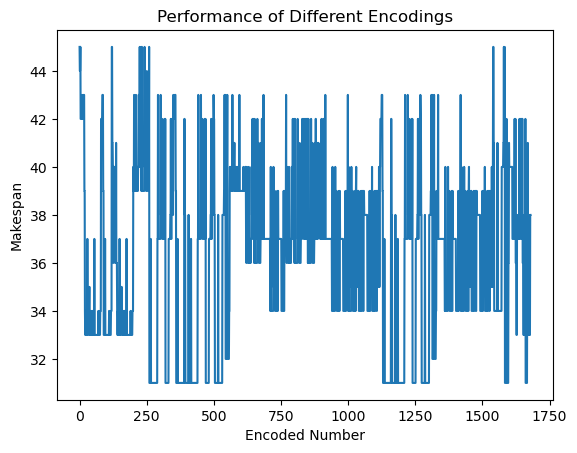

In [ ]:
print(list_of_lists_schedule)
print('#encoding integers:', total_encoding_count(example_problem))
Makespan_list = []
min_time = 1000000
min_decoded_ops = None

for encoded_number in range(total_encoding_count(example_problem)):
    sequence = decode_integer(encoded_number, example_problem)
    cost = makespan(sequence)
    Makespan_list.append(cost)
    if cost < min_time:
        min_time = cost
        min_encoded_number = encoded_number
        min_decoded_ops = [operation.op_id for operation, option in sequence]
    #print(f"Encoded number: {encoded_number}, 'Decoded op:', {[operation.op_id for operation, option in sequence]}, 'Makespan: {cost}")
print(f"Minimum makespan found: {min_time}")
print(f"Best sequence (encoded number {min_encoded_number}): {min_decoded_ops}")

plt.plot(range(total_encoding_count(example_problem)), Makespan_list)
plt.xlabel("Encoded Number")
plt.ylabel("Makespan")
plt.title("Performance of Different Encodings")
plt.show()

encoding_integers_9, Makespan_list_9 = range(total_encoding_count(example_problem)), Makespan_list
min_encoded_number_9 = min_encoded_number
min_decoded_ops_9 = min_decoded_ops
total_encodings_9 = total_encoding_count(example_problem)


### small Problem generation & makespan cost of all encoding integers

Time_array: [3, 8, 6, 9, 2, 1]
[[('M1', 3), ('M2', 8)], [('M1', 6), ('M2', 9)], [('M2', 2), ('M1', 1)]]
#encoding integers: 90
Encoded number: 0, 'Decoded op:', [0, 1, 2, 3, 4, 5], 'Makespan: 23
Encoded number: 1, 'Decoded op:', [0, 1, 2, 4, 3, 5], 'Makespan: 22
Encoded number: 2, 'Decoded op:', [0, 1, 2, 4, 5, 3], 'Makespan: 22
Encoded number: 3, 'Decoded op:', [0, 1, 4, 2, 3, 5], 'Makespan: 22
Encoded number: 4, 'Decoded op:', [0, 1, 4, 2, 5, 3], 'Makespan: 22
Encoded number: 5, 'Decoded op:', [0, 1, 4, 5, 2, 3], 'Makespan: 29
Encoded number: 6, 'Decoded op:', [0, 2, 1, 3, 4, 5], 'Makespan: 23
Encoded number: 7, 'Decoded op:', [0, 2, 1, 4, 3, 5], 'Makespan: 22
Encoded number: 8, 'Decoded op:', [0, 2, 1, 4, 5, 3], 'Makespan: 22
Encoded number: 9, 'Decoded op:', [0, 2, 3, 1, 4, 5], 'Makespan: 29
Encoded number: 10, 'Decoded op:', [0, 2, 3, 4, 1, 5], 'Makespan: 28
Encoded number: 11, 'Decoded op:', [0, 2, 3, 4, 5, 1], 'Makespan: 28
Encoded number: 12, 'Decoded op:', [0, 2, 4, 1, 3, 5], 

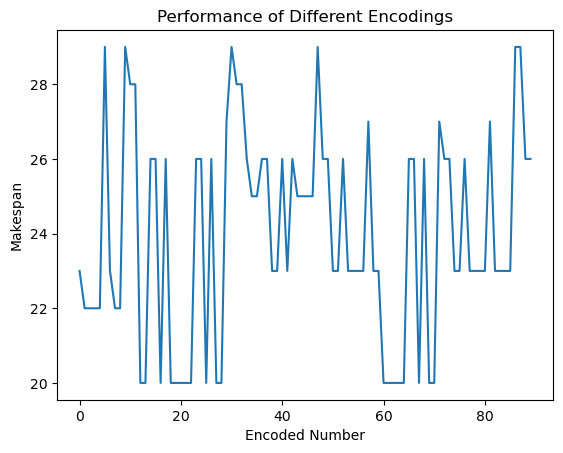

In [ ]:
arrays = [
    [1, 2],
    [4, 5],
    [7, 8]
]
Machine_arrays = [
    [1, 2],
    [1, 2],
    [2, 1]
]
#Time_array = np.array([1, 2, 4, 5, 7, 8])
Time_array = [int(rnd_Time_array[i]) for i in [0,1,3,4,6,7]]
print('Time_array:', Time_array)


items = []
for arr in arrays:
    items.extend(arr)
Machine_items = []
for arr in Machine_arrays:
    Machine_items.extend(arr)

list_of_lists_schedule = []
for i in range(len(arrays)):
    list_of_lists_schedule.append([])
#print(list_of_lists_schedule)
ii = 0
for i in range(len(arrays)):
    for i2 in range(len(arrays[i])):
        list_of_lists_schedule[i].append((f"M{Machine_items[ii+i2]}", int(Time_array[ii+i2])))
    ii = ii+len(arrays[i])
print(list_of_lists_schedule)

example_problem = make_problem( list_of_lists_schedule  )


print('#encoding integers:', total_encoding_count(example_problem))
Makespan_list = []
min_time = 1000000
min_decoded_ops = None
for encoded_number in range(total_encoding_count(example_problem)):
    sequence = decode_integer(encoded_number, example_problem)
    cost = makespan(sequence)
    Makespan_list.append(cost)
    if cost < min_time:
        min_time = cost
        min_encoded_number = encoded_number
        min_decoded_ops = [operation.op_id for operation, option in sequence]
    print(f"Encoded number: {encoded_number}, 'Decoded op:', {[operation.op_id for operation, option in sequence]}, 'Makespan: {cost}")
print(f"Minimum makespan found: {min_time}")
print(f"Best sequence (encoded number {min_encoded_number}): {min_decoded_ops}")

plt.plot(range(total_encoding_count(example_problem)), Makespan_list)
plt.xlabel("Encoded Number")
plt.ylabel("Makespan")
plt.title("Performance of Different Encodings")
plt.show()

encoding_integers_6, Makespan_list_6 = range(total_encoding_count(example_problem)), Makespan_list
min_encoded_number_6 = min_encoded_number
min_decoded_ops_6 = min_decoded_ops
total_encodings_6 = total_encoding_count(example_problem)

### very small Problem generation & makespan cost of all encoding integers

Time_array: [3, 8, 6, 9, 2]
[[('M1', 3), ('M2', 8)], [('M1', 6), ('M2', 9)], [('M2', 2)]]
#encoding integers: 30
Encoded number: 0, 'Decoded op:', [0, 1, 2, 3, 4], 'Makespan: 22
Encoded number: 1, 'Decoded op:', [0, 1, 2, 4, 3], 'Makespan: 22
Encoded number: 2, 'Decoded op:', [0, 1, 4, 2, 3], 'Makespan: 22
Encoded number: 3, 'Decoded op:', [0, 2, 1, 3, 4], 'Makespan: 22
Encoded number: 4, 'Decoded op:', [0, 2, 1, 4, 3], 'Makespan: 22
Encoded number: 5, 'Decoded op:', [0, 2, 3, 1, 4], 'Makespan: 28
Encoded number: 6, 'Decoded op:', [0, 2, 3, 4, 1], 'Makespan: 28
Encoded number: 7, 'Decoded op:', [0, 2, 4, 1, 3], 'Makespan: 20
Encoded number: 8, 'Decoded op:', [0, 2, 4, 3, 1], 'Makespan: 26
Encoded number: 9, 'Decoded op:', [0, 4, 1, 2, 3], 'Makespan: 20
Encoded number: 10, 'Decoded op:', [0, 4, 2, 1, 3], 'Makespan: 20
Encoded number: 11, 'Decoded op:', [0, 4, 2, 3, 1], 'Makespan: 26
Encoded number: 12, 'Decoded op:', [2, 0, 1, 3, 4], 'Makespan: 28
Encoded number: 13, 'Decoded op:', [2, 

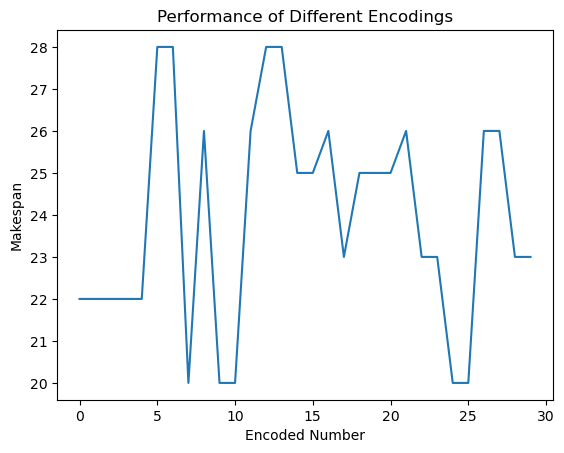

In [ ]:
arrays = [
    [1, 2],
    [4, 5],
    [7]
]
Machine_arrays = [
    [1, 2],
    [1, 2],
    [2]
]


Time_array = [int(rnd_Time_array[i]) for i in [0,1,3,4,6]]

print('Time_array:', Time_array)


items = []
for arr in arrays:
    items.extend(arr)
Machine_items = []
for arr in Machine_arrays:
    Machine_items.extend(arr)

list_of_lists_schedule = []
for i in range(len(arrays)):
    list_of_lists_schedule.append([])
#print(list_of_lists_schedule)
ii = 0
for i in range(len(arrays)):
    for i2 in range(len(arrays[i])):
        list_of_lists_schedule[i].append((f"M{Machine_items[ii+i2]}", int(Time_array[ii+i2])))
    ii = ii+len(arrays[i])
print(list_of_lists_schedule)

example_problem = make_problem( list_of_lists_schedule  )


print('#encoding integers:', total_encoding_count(example_problem))
Makespan_list = []
min_time = 1000000
min_decoded_ops = None
all_decoded_ops = []
for encoded_number in range(total_encoding_count(example_problem)):
    sequence = decode_integer(encoded_number, example_problem)
    cost = makespan(sequence)
    Makespan_list.append(cost)
    if cost < min_time:
        min_time = cost
        min_encoded_number = encoded_number
        min_decoded_ops = [operation.op_id for operation, option in sequence]
    all_decoded_ops.append([operation.op_id for operation, option in sequence])
    print(f"Encoded number: {encoded_number}, 'Decoded op:', {[operation.op_id for operation, option in sequence]}, 'Makespan: {cost}")
print(f"Minimum makespan found: {min_time}")
print(f"Best sequence (encoded number {min_encoded_number}): {min_decoded_ops}")

plt.plot(range(total_encoding_count(example_problem)), Makespan_list)
plt.xlabel("Encoded Number")
plt.ylabel("Makespan")
plt.title("Performance of Different Encodings")
plt.show()

encoding_integers_5, Makespan_list_5 = range(total_encoding_count(example_problem)), Makespan_list
min_encoded_number_5 = min_encoded_number
min_decoded_ops_5 = min_decoded_ops
total_encodings_5 = total_encoding_count(example_problem)
all_decoded_ops_5 = all_decoded_ops

### compare 9 6 5

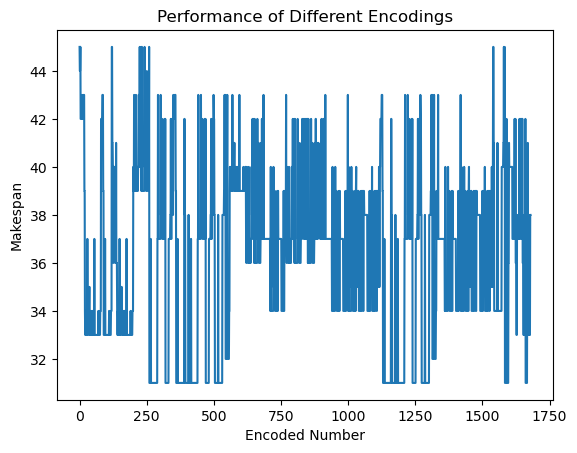

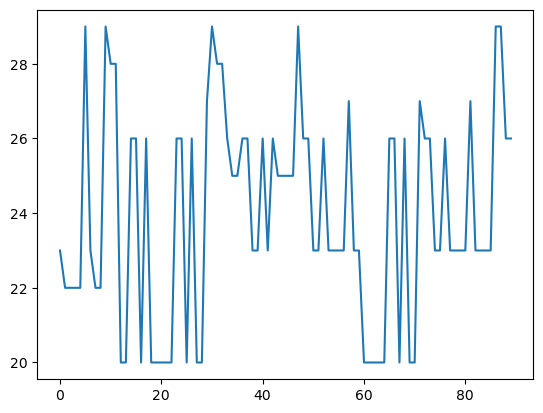

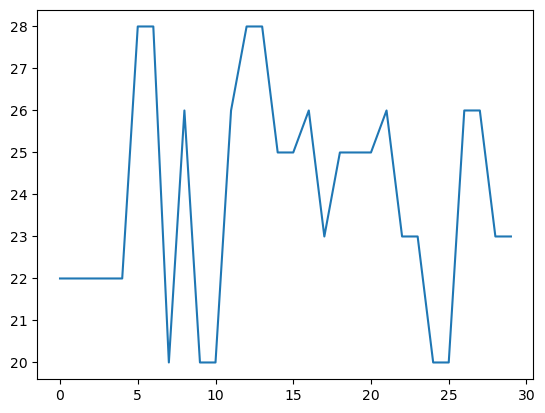

In [ ]:
plt.plot(encoding_integers_9, Makespan_list_9)
plt.xlabel("Encoded Number")
plt.ylabel("Makespan")
plt.title("Performance of Different Encodings")
plt.show()

plt.plot(encoding_integers_6, Makespan_list_6)
plt.show()

plt.plot(encoding_integers_5, Makespan_list_5)
plt.show()

min encoding number: 260 12 7
total encodings:   1680 90 30
normalized min encoding number: 0.15476190476190477 0.13333333333333333 0.23333333333333334
min dec ops:      [0, 3, 6, 1, 2, 4, 5, 7, 8] [0, 2, 4, 1, 3, 5] [0, 2, 4, 1, 3]
min dec ops_to_9: [0, 3, 6, 1, 2, 4, 5, 7, 8] [0, 3, 6, 1, 4, 7] [0, 3, 6, 1, 4]
min dec ops_6_&_5_from_9:  [0, 3, 6, 1, 4, 7] [0, 3, 6, 1, 4]
min dec ops_6_&_5_from_9_: [0, 2, 4, 1, 3, 5] [0, 2, 4, 1, 3]


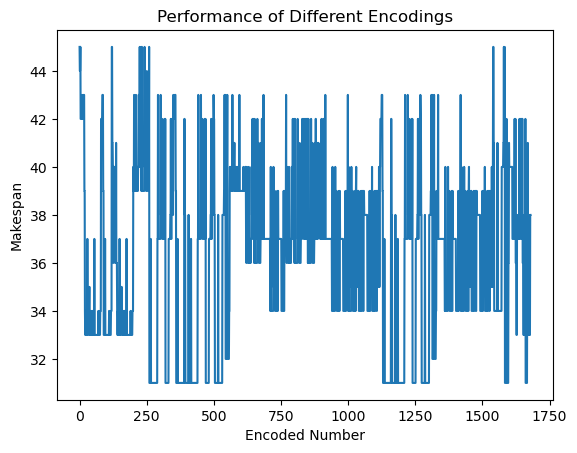

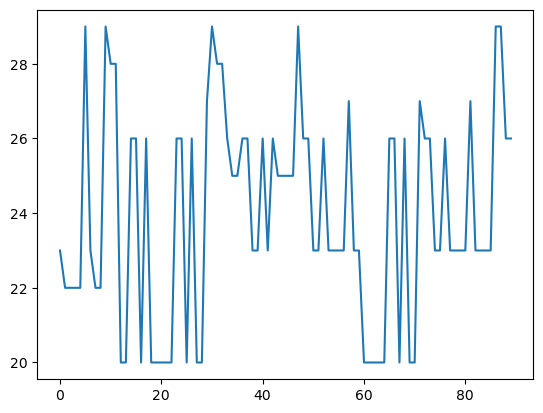

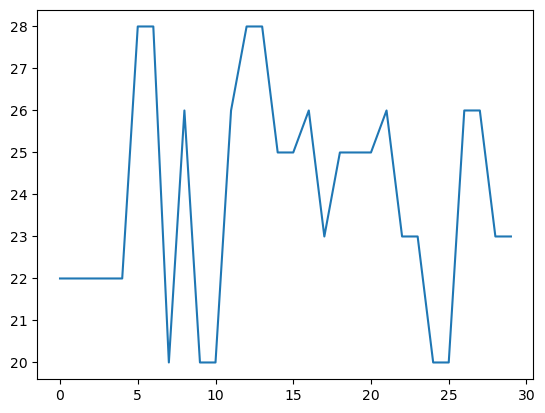

In [ ]:
print('min encoding number:', min_encoded_number_9, min_encoded_number_6, min_encoded_number_5)
print('total encodings:  ', total_encodings_9, total_encodings_6, total_encodings_5)
print('normalized min encoding number:', min_encoded_number_9/total_encodings_9, min_encoded_number_6/total_encodings_6, min_encoded_number_5/total_encodings_5)
min_decoded_ops_9_ = min_decoded_ops_9.copy()
min_decoded_ops_6_ = min_decoded_ops_6.copy()
min_decoded_ops_5_ = min_decoded_ops_5.copy()
for i in range(6):
    if min_decoded_ops_6[i] >= 2 and min_decoded_ops_6[i] <= 3:
        min_decoded_ops_6_[i] = min_decoded_ops_6[i]+1
    elif min_decoded_ops_6[i] >= 4 and min_decoded_ops_6[i] <= 5:
        min_decoded_ops_6_[i] = min_decoded_ops_6[i]+2
for i in range(5):
    if min_decoded_ops_5[i] >= 2 and min_decoded_ops_5[i] <= 3:
        min_decoded_ops_5_[i] = min_decoded_ops_5[i]+1
    elif min_decoded_ops_5[i] == 4:
        min_decoded_ops_5_[i] = min_decoded_ops_5[i]+2
print('min dec ops:     ', min_decoded_ops_9, min_decoded_ops_6, min_decoded_ops_5)
print('min dec ops_to_9:', min_decoded_ops_9_, min_decoded_ops_6_, min_decoded_ops_5_)
min_decoded_ops_6_from_9 = min_decoded_ops_9.copy()
min_decoded_ops_6_from_9.remove(8)
min_decoded_ops_6_from_9.remove(5)
min_decoded_ops_6_from_9.remove(2)
min_decoded_ops_5_from_9 = min_decoded_ops_6_from_9.copy()
min_decoded_ops_5_from_9.remove(7)
min_decoded_ops_6_from_9_ = min_decoded_ops_6_from_9.copy()
min_decoded_ops_5_from_9_ = min_decoded_ops_5_from_9.copy()
for i in range(6):
    if min_decoded_ops_6_from_9[i] >= 3 and min_decoded_ops_6_from_9[i] <= 5:
        min_decoded_ops_6_from_9_[i] = min_decoded_ops_6_from_9[i]-1
    elif min_decoded_ops_6_from_9[i] >= 6:
        min_decoded_ops_6_from_9_[i] = min_decoded_ops_6_from_9[i]-2
for i in range(5):
    if min_decoded_ops_5_from_9[i] >= 3 and min_decoded_ops_5_from_9[i] <= 5:
        min_decoded_ops_5_from_9_[i] = min_decoded_ops_5_from_9[i]-1
    elif min_decoded_ops_5_from_9[i] >= 6:
        min_decoded_ops_5_from_9_[i] = min_decoded_ops_5_from_9[i]-2
print('min dec ops_6_&_5_from_9: ', min_decoded_ops_6_from_9, min_decoded_ops_5_from_9)
print('min dec ops_6_&_5_from_9_:', min_decoded_ops_6_from_9_, min_decoded_ops_5_from_9_)

plt.plot(encoding_integers_9, Makespan_list_9)
plt.xlabel("Encoded Number")
plt.ylabel("Makespan")
plt.title("Performance of Different Encodings")
plt.show()

plt.plot(encoding_integers_6, Makespan_list_6)
plt.show()

plt.plot(encoding_integers_5, Makespan_list_5)
plt.show()

### Generate Schedule nxm, truncated n2xm2, Reindexed truncated n2xm2

In [ ]:
import numpy as np

def truncate_and_reindex(n, m, n2, m2):
    """
    Create an n x m matrix with values 0 to n*m-1,
    truncate it to n2 x m2, and create a reindexed copy
    with values 0 to n2*m2-1.

    Parameters:
        n, m  : Original matrix dimensions
        n2, m2: Truncated matrix dimensions (n2 <= n, m2 <= m)

    Returns:
        original  : Original n x m matrix
        truncated : Top-left n2 x m2 portion
        reindexed : n2 x m2 matrix with values 0 to n2*m2-1
    """
    if n2 > n or m2 > m:
        raise ValueError("Truncated dimensions must not exceed original dimensions.")

    # Original matrix
    original = np.arange(n * m).reshape(n, m)

    # Truncate (top-left corner)
    truncated = original[:n2, :m2]

    # Reindex
    reindexed = np.arange(n2 * m2).reshape(n2, m2)

    return original, truncated, reindexed


# Example
n, m = 5, 6
n2, m2 = 3, 4

original, truncated, reindexed = truncate_and_reindex(n, m, n2, m2)

print("Original matrix:")
print(original)

print("\nTruncated matrix:")
print(truncated)

print("\nReindexed truncated matrix:")
print(reindexed)

Original matrix:
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]
 [24 25 26 27 28 29]]

Truncated matrix:
[[ 0  1  2  3]
 [ 6  7  8  9]
 [12 13 14 15]]

Reindexed truncated matrix:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


### Generate Schedule of different n,m

In [ ]:
for n in range(2,6):   #  No of Jobs
    for m in range(2,6): # No of Operations in each Job

        Schedule_nm = np.arange(n * m).reshape(n, m)

        print(f'\n n={n}, m={m}: \n', Schedule_nm)


 n=2, m=2: 
 [[0 1]
 [2 3]]

 n=2, m=3: 
 [[0 1 2]
 [3 4 5]]

 n=2, m=4: 
 [[0 1 2 3]
 [4 5 6 7]]

 n=2, m=5: 
 [[0 1 2 3 4]
 [5 6 7 8 9]]

 n=3, m=2: 
 [[0 1]
 [2 3]
 [4 5]]

 n=3, m=3: 
 [[0 1 2]
 [3 4 5]
 [6 7 8]]

 n=3, m=4: 
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

 n=3, m=5: 
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]

 n=4, m=2: 
 [[0 1]
 [2 3]
 [4 5]
 [6 7]]

 n=4, m=3: 
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]

 n=4, m=4: 
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]

 n=4, m=5: 
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]

 n=5, m=2: 
 [[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]

 n=5, m=3: 
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]

 n=5, m=4: 
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]]

 n=5, m=5: 
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


### Convert 1D schedule from higher (nxm) to lower (n2xm2)

In [ ]:
import numpy as np

def truncate_and_reindex_random(n, m, n2, m2, seed=None, dec_ops=None):
    if seed is not None:
        np.random.seed(seed)

    # Original matrix
    original = np.arange(n * m).reshape(n, m)

    # Truncated original matrix
    truncated = original[:n2, :m2]

    # Reindexed truncated matrix
    reindexed = np.arange(n2 * m2).reshape(n2, m2)

    # Random 1D permutation of all elements
    if dec_ops is not None:
        random_array = np.array(dec_ops)
    else:
        random_array = np.random.permutation(original.ravel())

    # Build mapping: original value -> reindexed value
    mapping = dict(zip(truncated.ravel(), reindexed.ravel()))

    # Keep only values present in truncated matrix
    mask = np.isin(random_array, truncated)

    truncated_1d = random_array[mask]

    # Replace values using the mapping
    reindexed_1d = np.array([mapping[x] for x in truncated_1d])

    return (original,
            truncated,
            reindexed,
            random_array,
            truncated_1d,
            reindexed_1d)


# Example
original, truncated, reindexed, random_array, truncated_1d, reindexed_1d = \
    truncate_and_reindex_random(5, 6, 3, 4, seed=42)


original, truncated, reindexed, random_array, truncated_1d, reindexed_1d = \
    truncate_and_reindex_random(3, 5, 3, 4, seed=42, dec_ops=[0, 1, 4, 8, 9, 2, 3, 5, 6, 10, 11, 7])


print("Random array:")
print(random_array)

print("\nTruncated 1D array:")
print(truncated_1d)

print("\nReindexed 1D array:")
print(reindexed_1d)

Random array:
[ 0  1  4  8  9  2  3  5  6 10 11  7]

Truncated 1D array:
[ 0  1  8  2  3  5  6 10 11  7]

Reindexed 1D array:
[0 1 7 2 3 4 5 8 9 6]


### Convert 1D schedule from lower (n2xm2) to higher (but n2xm2 only)

In [ ]:
min_jobs = 2; curr_jobs = 3
min_ops_in_job = 2; curr_ops_in_job = 5

minProblemSize_decoded_ops = [0, 1, 2, 3]
minProblemSize_to_currProblemSize_decoded_ops = minProblemSize_decoded_ops.copy()

def minProblemSize_to_currProblemSize_decoded_ops_fn(min_jobs, curr_jobs, min_ops_in_job, curr_ops_in_job, minProblemSize_decoded_ops):
    for i in range(len(minProblemSize_decoded_ops)):
        for m in range(min_jobs):
            if minProblemSize_decoded_ops[i] >= m*min_ops_in_job and minProblemSize_decoded_ops[i] < (m+1)*min_ops_in_job:
                minProblemSize_to_currProblemSize_decoded_ops[i] += m*(curr_ops_in_job - min_ops_in_job)
    return minProblemSize_to_currProblemSize_decoded_ops

minProblemSize_to_currProblemSize_decoded_ops =minProblemSize_to_currProblemSize_decoded_ops_fn(min_jobs, curr_jobs, min_ops_in_job, curr_ops_in_job, minProblemSize_decoded_ops)
print('minProblemSize_decoded_ops:                   ', minProblemSize_decoded_ops)
print('minProblemSize_to_currProblemSize_decoded_ops:', minProblemSize_to_currProblemSize_decoded_ops)

minProblemSize_decoded_ops:                    [0, 1, 2, 3]
minProblemSize_to_currProblemSize_decoded_ops: [0, 1, 5, 6]


## 8. Cost Before and After Filtering

Before filtering, the cost is just makespan:

```text
C(x) = makespan of schedule x
```

F-VQE uses a filter function to turn cost into a reward.

For the inverse filter with strength `t`:

```text
F_t(C) = 1 / (C - C_shift)^t
```

where usually:

```text
C_shift = C_min - 1
```

Lower makespan gives a larger filtered reward.

In [ ]:
def all_raw_costs(problem):
    """Return raw makespan cost for each valid encoding."""

    costs = []

    for encoded_number in range(total_encoding_count(problem)):
        sequence = decode_integer(encoded_number, problem)
        costs.append(makespan(sequence))

    return np.array(costs, dtype=float)


def filtered_reward(costs, filter_type="inverse", strength=1.0):
    """Convert raw costs into filtered rewards.

    Higher reward is better.
    Lower raw cost creates higher reward.
    """

    minimum_cost = np.min(costs)
    cost_shift = minimum_cost - 1.0

    if filter_type == "inverse":
        return 1.0 / ((costs - cost_shift) ** strength)

    if filter_type == "exponential":
        return np.exp(-strength * (costs - minimum_cost))

    if filter_type == "power":
        return 1.0 / ((costs - cost_shift) ** strength)

    raise ValueError("Unknown filter type")


raw_costs = all_raw_costs(example_problem)
rewards = filtered_reward(raw_costs, filter_type="inverse", strength=2.0)

print("Encoding | Raw makespan | Filtered reward")
for encoded_number, cost, reward in zip(range(len(raw_costs)), raw_costs, rewards):
    print(f"{encoded_number:8d} | {cost:12.1f} | {reward:15.6f}")

Encoding | Raw makespan | Filtered reward
       0 |         23.0 |        0.015625
       1 |         20.0 |        0.040000
       2 |         20.0 |        0.040000
       3 |         23.0 |        0.015625
       4 |         20.0 |        0.040000
       5 |         29.0 |        0.005102
       6 |         29.0 |        0.005102
       7 |         16.0 |        1.000000
       8 |         22.0 |        0.020408
       9 |         16.0 |        1.000000
      10 |         16.0 |        1.000000
      11 |         22.0 |        0.020408
      12 |         29.0 |        0.005102
      13 |         29.0 |        0.005102
      14 |         26.0 |        0.008264
      15 |         25.0 |        0.010000
      16 |         22.0 |        0.020408
      17 |         19.0 |        0.062500
      18 |         26.0 |        0.008264
      19 |         25.0 |        0.010000
      20 |         25.0 |        0.010000
      21 |         22.0 |        0.020408
      22 |         19.0 |        0

## 9. Make a Cost Array for All Quantum Basis States

If we need `n` qubits, the quantum state has `2^n` basis states.

But sometimes:

```text
2^n > number of valid encodings
```

Those extra states are invalid. We assign them a large penalty cost.

In [ ]:
def cost_array_for_quantum_states(problem):
    """Create a cost value for every quantum basis state."""

    qubits = number_of_qubits(problem)
    state_count = 2 ** qubits
    valid_count = total_encoding_count(problem)

    valid_costs = all_raw_costs(problem)

    # Invalid states get a penalty larger than all valid costs.
    penalty = np.max(valid_costs) + max(1.0, np.max(valid_costs) - np.min(valid_costs))

    costs = np.full(state_count, penalty, dtype=float)
    costs[:valid_count] = valid_costs

    return costs

## 10. A Simple Simulated Quantum Circuit

This notebook uses a small statevector simulator instead of Qiskit.

The ansatz circuit is:

1. Apply `Ry(theta)` rotations to every qubit.
2. Apply `CNOT` gates to entangle neighboring qubits.
3. Repeat for several layers.

The output is a probability for every bitstring.

In [ ]:
def zero_state(qubits):
    """Return |00...0> as a statevector."""

    state_count = 2 ** qubits
    state = np.zeros(state_count, dtype=np.complex128)
    state[0] = 1.0
    return state


def apply_ry_gate(state, qubits, target_qubit, theta):
    """Apply an Ry rotation to one qubit.

    This updates the statevector directly.
    """

    cos_value = np.cos(theta / 2.0)
    sin_value = np.sin(theta / 2.0)
    target_bit = 2 ** target_qubit

    for block_start in range(0, len(state), 2 * target_bit):
        for offset in range(target_bit):
            index_0 = block_start + offset
            index_1 = index_0 + target_bit

            old_0 = state[index_0]
            old_1 = state[index_1]

            state[index_0] = cos_value * old_0 - sin_value * old_1
            state[index_1] = sin_value * old_0 + cos_value * old_1


def apply_cnot_gate(state, control_qubit, target_qubit):
    """Apply a CNOT gate to the statevector."""

    control_bit = 2 ** control_qubit
    target_bit = 2 ** target_qubit

    for index in range(len(state)):
        control_is_one = (index & control_bit) != 0
        target_is_zero = (index & target_bit) == 0

        if control_is_one and target_is_zero:
            partner_index = index | target_bit
            state[index], state[partner_index] = state[partner_index], state[index]


def parameter_count(qubits, layers):
    """Each rotation layer has one angle per qubit."""
    return (layers + 1) * qubits


def run_ansatz(parameters, qubits, layers):
    """Run the simple variational circuit and return final statevector."""

    state = zero_state(qubits)
    parameter_index = 0

    for layer in range(layers + 1):
        # Rotation part
        for qubit in range(qubits):
            theta = parameters[parameter_index]
            apply_ry_gate(state, qubits, qubit, theta)
            parameter_index = parameter_index + 1

        # Entangling part
        if layer < layers:
            for qubit in range(qubits - 1):
                apply_cnot_gate(state, control_qubit=qubit, target_qubit=qubit + 1)

    return state


def probabilities_from_circuit(parameters, qubits, layers):
    """Convert final statevector amplitudes into probabilities."""

    state = run_ansatz(parameters, qubits, layers)
    probabilities = np.abs(state) ** 2
    probabilities = probabilities / np.sum(probabilities)
    return probabilities

## 11. F-VQE Objective

F-VQE does not directly minimize makespan.

Instead, it maximizes the **expected filtered reward**:

```text
objective = sum probability(bitstring) * filtered_reward(bitstring)
```

In sampled mode, we estimate this by measuring bitstrings and averaging their filtered rewards.

In [ ]:
def sample_bitstrings(probabilities, shots, random_generator):
    """Sample basis-state integers according to circuit probabilities."""

    state_count = len(probabilities)
    return random_generator.choice(state_count, size=shots, p=probabilities)


def fvqe_objective(parameters, costs, qubits, layers, shots, random_generator, filter_type="inverse", strength=1.0):
    """Estimate the F-VQE objective from sampled bitstrings."""

    probabilities = probabilities_from_circuit(parameters, qubits, layers)
    samples = sample_bitstrings(probabilities, shots, random_generator)

    sampled_costs = costs[samples]
    sampled_rewards = filtered_reward(sampled_costs, filter_type=filter_type, strength=strength)

    return np.mean(sampled_rewards)


def best_schedule_from_samples(problem, samples):
    """Find the best valid schedule among measured samples."""

    valid_count = total_encoding_count(problem)
    valid_samples = []

    for value in samples:
        if value < valid_count:
            valid_samples.append(int(value))

    if len(valid_samples) == 0:
        return None, None, None

    best_number = None
    best_cost = None
    best_sequence = None

    for encoded_number in sorted(set(valid_samples)):
        sequence = decode_integer(encoded_number, problem)
        cost = makespan(sequence)

        if best_cost is None or cost < best_cost:
            best_number = encoded_number
            best_cost = cost
            best_sequence = sequence

    return best_number, best_cost, best_sequence

## 12. Simple F-VQE Training Loop

We use a simple SPSA-style update:

1. Randomly perturb all parameters.
2. Evaluate objective at `theta + perturbation`.
3. Evaluate objective at `theta - perturbation`.
4. Estimate a gradient direction.
5. Move parameters toward the better direction.

This is not the only optimizer possible, but it is beginner-friendly and common for noisy variational algorithms.

In [ ]:
def run_fvqe(
    problem,
    layers=2,
    iterations=80,
    shots=512,
    filter_type="inverse",
    filter_strength=2.0,
    learning_rate=0.25,
    perturbation_size=0.20,
    seed=123,
):
    """Run a small simulated F-VQE optimization."""

    rng = np.random.default_rng(seed)

    qubits = number_of_qubits(problem)
    costs = cost_array_for_quantum_states(problem)

    # Start with small random parameters.
    parameters = rng.uniform(-0.05, 0.05, size=parameter_count(qubits, layers))

    best_number = None
    best_cost = None
    best_sequence = None
    history = []

    for iteration in range(1, iterations + 1):
        # SPSA uses random +1/-1 directions.
        direction = rng.choice([-1.0, 1.0], size=len(parameters))

        theta_plus = parameters + perturbation_size * direction
        theta_minus = parameters - perturbation_size * direction

        objective_plus = fvqe_objective(
            theta_plus, costs, qubits, layers, shots, rng,
            filter_type=filter_type, strength=filter_strength,
        )

        objective_minus = fvqe_objective(
            theta_minus, costs, qubits, layers, shots, rng,
            filter_type=filter_type, strength=filter_strength,
        )

        # Estimate gradient and update parameters.
        gradient_estimate = (objective_plus - objective_minus) * direction / (2.0 * perturbation_size)
        parameters = parameters + learning_rate * gradient_estimate

        # Measure the current circuit and keep the best sampled valid schedule.
        probabilities = probabilities_from_circuit(parameters, qubits, layers)
        samples = sample_bitstrings(probabilities, shots, rng)
        candidate_number, candidate_cost, candidate_sequence = best_schedule_from_samples(problem, samples)

        if candidate_cost is not None:
            if best_cost is None or candidate_cost < best_cost:
                best_number = candidate_number
                best_cost = candidate_cost
                best_sequence = candidate_sequence

        history.append(
            {
                "iteration": iteration,
                "objective_plus": objective_plus,
                "objective_minus": objective_minus,
                "candidate_cost": candidate_cost,
                "best_cost": best_cost,
            }
        )

    return best_number, best_cost, best_sequence, history

## 13. Run F-VQE on the Example Problem

In [ ]:
fvqe_number, fvqe_cost, fvqe_sequence, fvqe_history = run_fvqe(
    example_problem,
    layers=2,
    iterations=100,
    shots=512,
    filter_type="inverse",
    filter_strength=2.0,
    learning_rate=0.25,
    perturbation_size=0.20,
    seed=11,
)

exact_number, exact_cost, exact_sequence = exhaustive_search(example_problem)

print("F-VQE best encoding:", fvqe_number)
print("F-VQE best makespan:", fvqe_cost)
print("Exact best makespan:", exact_cost)
print("\nF-VQE schedule:")
print_schedule(build_schedule(fvqe_sequence))

F-VQE best encoding: 24
F-VQE best makespan: 16
Exact best makespan: 16

F-VQE schedule:
Operation O4 (Job 2) on M2: start=0, finish=7
Operation O0 (Job 0) on M1: start=0, finish=4
Operation O1 (Job 0) on M2: start=7, finish=13
Operation O2 (Job 1) on M1: start=4, finish=13
Operation O3 (Job 1) on M2: start=13, finish=16


## 14. Flexible JSP Example

Now one operation has two possible machine choices.

In [ ]:
flexible_problem = make_problem(
    [
        [[("M1", 3), ("M2", 4)], ("M2", 2)],
        [("M1", 2)],
    ]
)

print("Total valid encodings:", total_encoding_count(flexible_problem))
print("Qubits needed:", number_of_qubits(flexible_problem))

flex_number, flex_cost, flex_sequence, flex_history = run_fvqe(
    flexible_problem,
    layers=2,
    iterations=100,
    shots=512,
    filter_type="inverse",
    filter_strength=2.0,
    learning_rate=0.25,
    perturbation_size=0.20,
    seed=21,
)

flex_exact_number, flex_exact_cost, flex_exact_sequence = exhaustive_search(flexible_problem)

print("\nF-VQE best encoding:", flex_number)
print("F-VQE best makespan:", flex_cost)
print("Exact best makespan:", flex_exact_cost)
print("\nF-VQE schedule:")
print_schedule(build_schedule(flex_sequence))

Total valid encodings: 6
Qubits needed: 3

F-VQE best encoding: 0
F-VQE best makespan: 5
Exact best makespan: 5

F-VQE schedule:
Operation O0 (Job 0) on M1: start=0, finish=3
Operation O1 (Job 0) on M2: start=3, finish=5
Operation O2 (Job 1) on M1: start=3, finish=5


## 15. What to Modify First

Good beginner experiments:

1. Change operation durations in `example_problem`.
2. Change `filter_strength`.
3. Change `shots`.
4. Change `iterations`.
5. Add more jobs or more flexible machine options.

Important idea:

- Exhaustive search checks every schedule, so it is exact but grows quickly.
- F-VQE samples from a parameterized circuit, so it is approximate and intended for larger search spaces.